# WISE on BPIC'19 — full analysis (all views × all artefacts)

The paper shows each artefact for **one** representative view. This notebook computes
the **complete picture**: every artefact for **all four stakeholder views**
(Finance, Logistics, Compliance, Automation), every layer, plus cross-view
comparisons. All figures are saved to **`figures/full/`**; the last cell is a figure
index. Use it to choose alternative/supplementary figures for the paper or appendix.

**Quickstart:** put your `BPI_Challenge_2019.csv` into the `data/` folder → *Run All*.

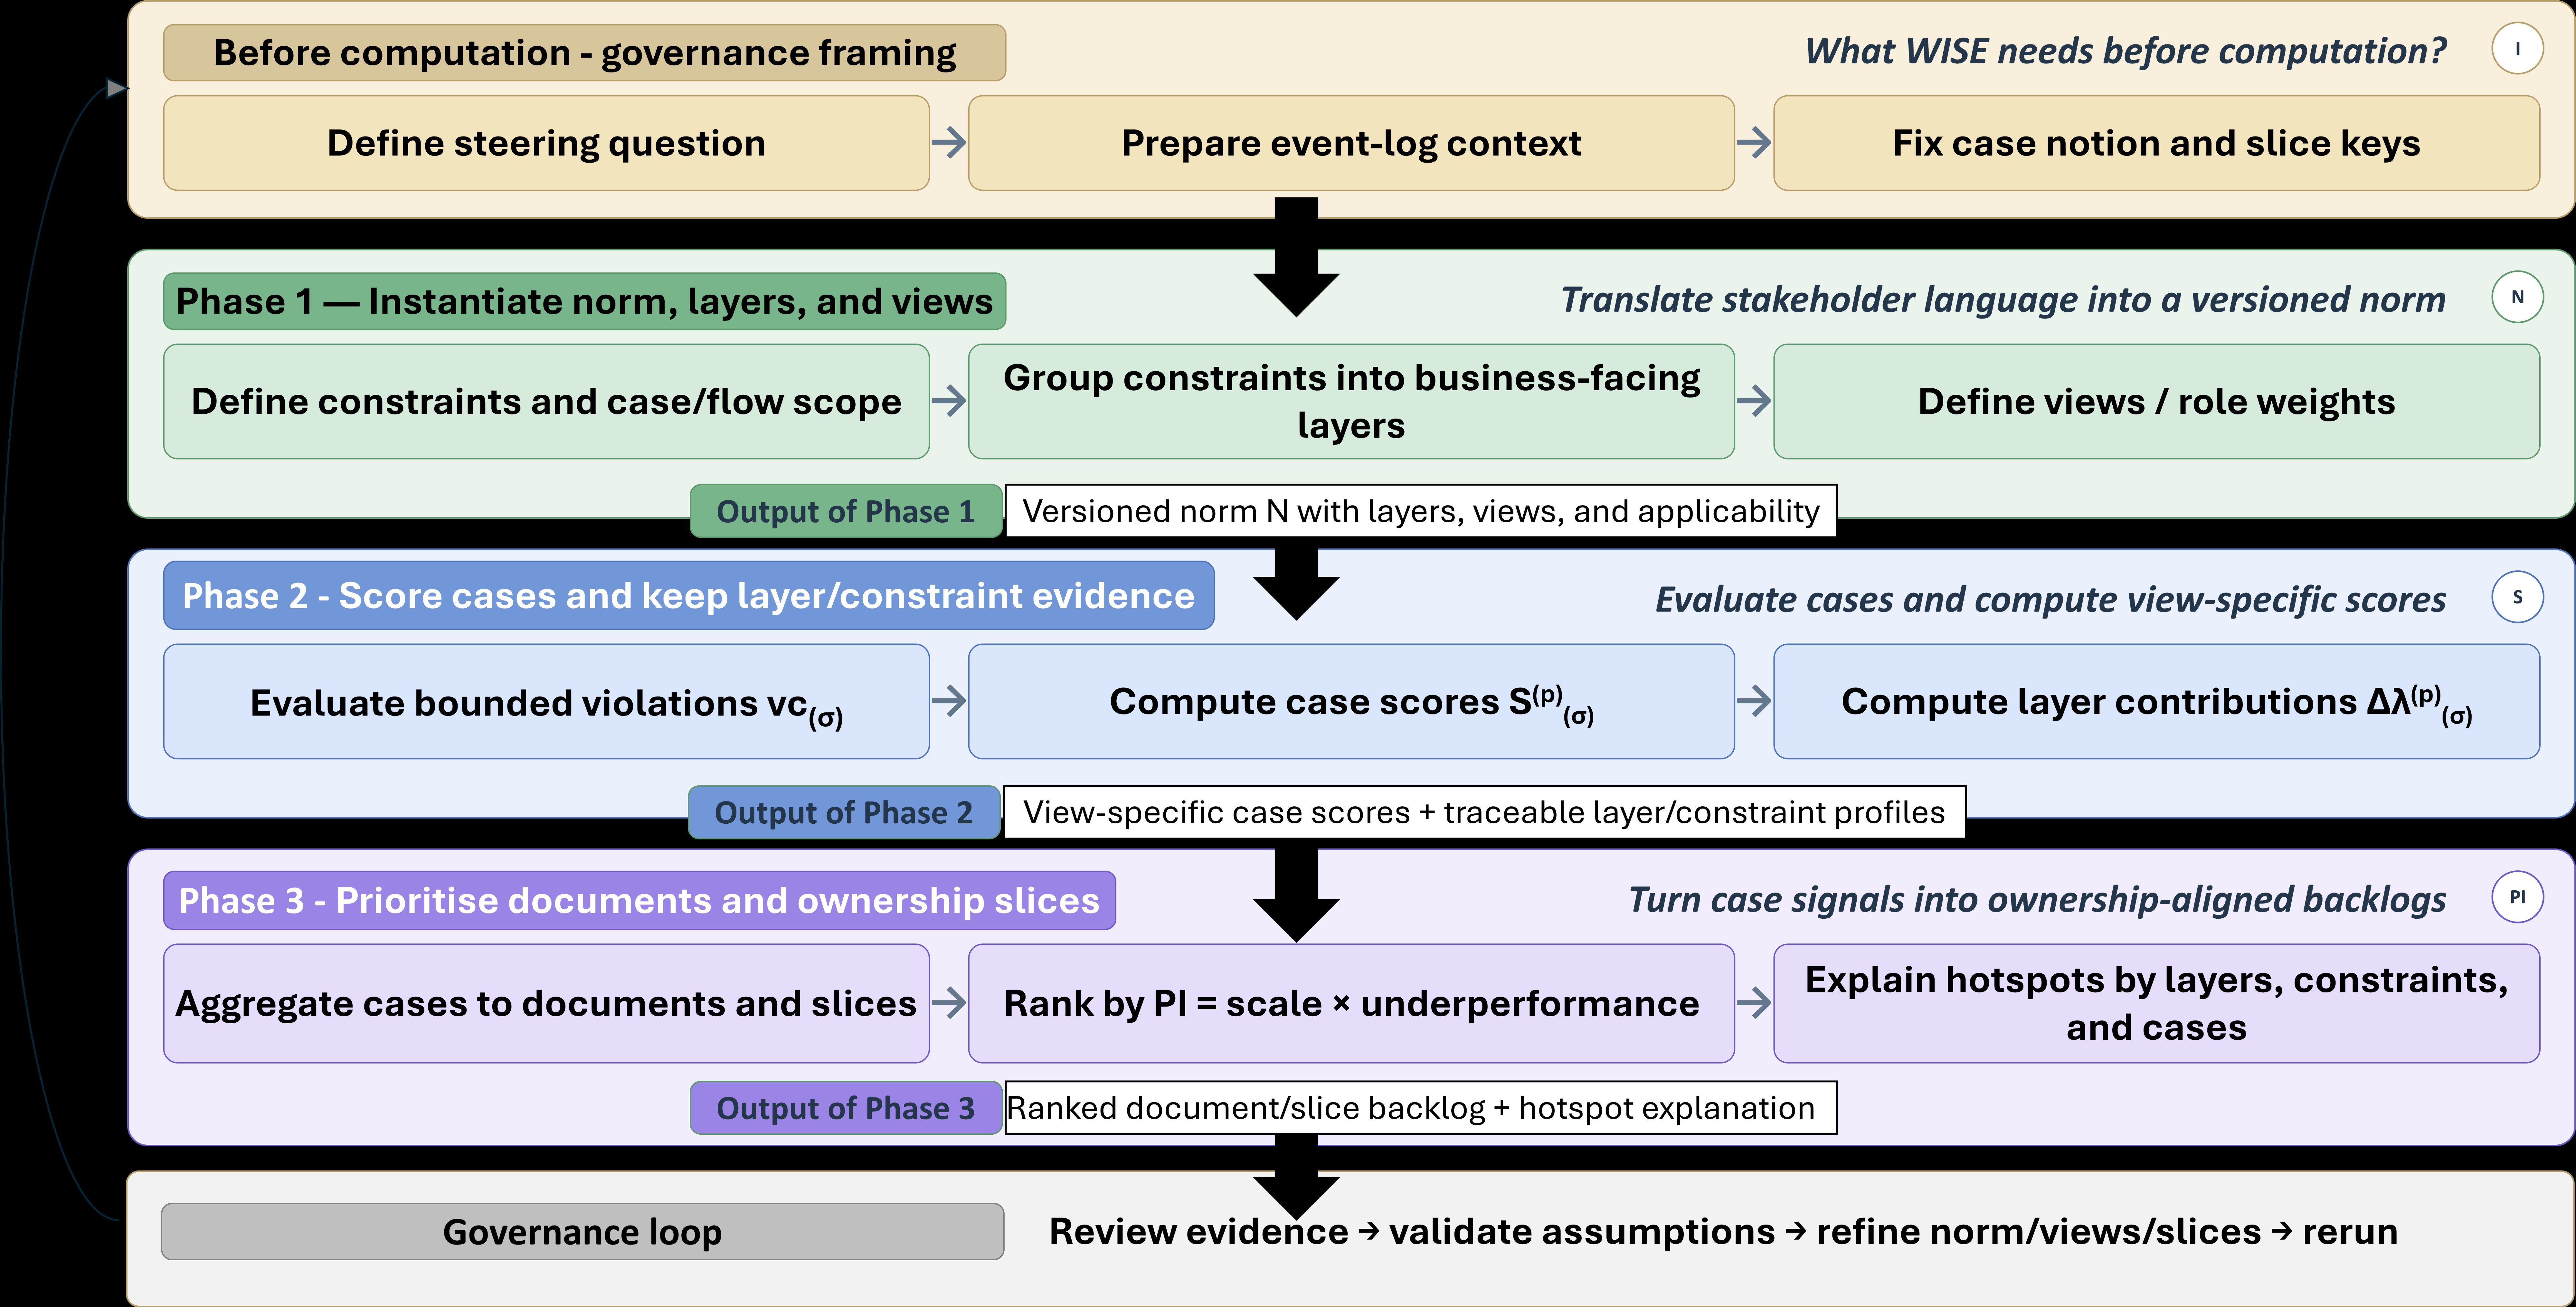

In [53]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===========================================================================
#  DATA LOCATION — the only thing you normally need to set.
#  Leave None  ->  the  data/  folder next to this notebook is used
#                  (any *.csv inside it is found automatically).
#  Or point it at your folder, e.g.  r"C:\Code\WISE_github\WISE\data"
# ===========================================================================
DATA_DIR_OVERRIDE = None

# --- locate the project root (folder containing wise_eval/) ---------------
import sys, os
from pathlib import Path

def _project_root():
    nb_path = globals().get("__vsc_ipynb_file__")
    if nb_path:
        p = Path(nb_path).resolve().parent
        if (p / "wise_eval" / "__init__.py").exists():
            return p
        if (p.parent / "wise_eval" / "__init__.py").exists():
            return p.parent
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "wise_eval" / "__init__.py").exists():
            return p
    for sub in sorted(Path.cwd().iterdir()):
        if sub.is_dir() and (sub / "wise_eval" / "__init__.py").exists():
            return sub
    raise FileNotFoundError("wise_eval/ not found — keep this notebook inside "
                            "the project folder and open that folder in VS Code/Jupyter.")

PROJECT_ROOT = _project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from wise_eval.config import CONFIG, RNG_SEED
from wise_eval import data as wdata, features as wfeat, norm as wnorm
from wise_eval import constraints as wcons, scoring as wsc
from wise_eval import prioritization as prio, governance as gov, viz

if DATA_DIR_OVERRIDE:
    CONFIG["csv_search_dirs"].insert(0, str(DATA_DIR_OVERRIDE))
    CONFIG["csv_candidates"].insert(0, str(Path(DATA_DIR_OVERRIDE) / "BPI_Challenge_2019.csv"))

# All figures of this notebook are written here (full load, every artefact):
CONFIG["figures_dir"] = str(PROJECT_ROOT / "figures" / "full")
Path(CONFIG["figures_dir"]).mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200); pd.set_option("display.width", 240)
np.random.seed(RNG_SEED)
VIEWS = ["Finance", "Logistics", "Compliance", "Automation"]
print(f"project root : {PROJECT_ROOT}")
print(f"figures dir  : {CONFIG['figures_dir']}")


project root : /Users/ula/code/PhD/WISE/WISE/Untitled
figures dir  : /Users/ula/code/PhD/WISE/WISE/Untitled/figures/full


In [28]:
# --- Load & prepare the event log (governance framing: fix the case notion) ---
df_raw, SOURCE, csv_path = wdata.load_raw_log()
df = wdata.prepare_log(df_raw)
n_docs = df["purchasing_document"].nunique()
print(f"\nData source : {SOURCE}" + (f"  ({csv_path})" if csv_path else "  (synthetic fallback with planted hotspots)"))
print(f"Event log   : {len(df):,} events | {df['case_id'].nunique():,} PO items | {n_docs:,} purchasing documents")
print("\nFlow-type case distribution (applicability backbone of the norm, paper Sec. V-A):")
flow_tab = (df.groupby("flow_type")["case_id"].nunique().rename("PO items")
            .to_frame().assign(share=lambda t: (t["PO items"]/t["PO items"].sum()).round(3)))
display(flow_tab)


[data] loading REAL BPIC'19 log: /Users/ula/code/PhD/WISE/WISE/Untitled/data/BPI_Challenge_2019.csv
[data] read 1,595,923 rows x 22 columns

Data source : BPIC19  (/Users/ula/code/PhD/WISE/WISE/Untitled/data/BPI_Challenge_2019.csv)
Event log   : 1,595,923 events | 251,734 PO items | 76,349 purchasing documents

Flow-type case distribution (applicability backbone of the norm, paper Sec. V-A):


,PO items,share
flow_type,,
2-way,1044,0.004
Consignment,14498,0.058
DF1,15182,0.060
DF2,221010,0.878


In [29]:
# --- Phases 1+2: norm, bounded violations ν_c(σ), view scores S^(p)(σ), layer contributions Δλ ---
fc   = wfeat.build_case_features(df)
norm = wnorm.load_norm()
dfv, V, M = wcons.build_violation_matrix(fc, norm)
dflp = wsc.compute_layer_penalties(dfv, norm)
dvs, dcontrib = wsc.compute_view_scores(dflp, norm)
scores = wsc.assemble_case_scores(fc, dfv, dflp, dvs, dcontrib)

print(f"Norm: {len(norm['constraints'])} constraints in {len(norm['layers'])} layers | "
      f"V (cases × constraints): {V.shape} | applicability density M̄ = {M.mean():.1%}")
print("\nGLOBAL BASELINES μ̄^(p)   [paper Sec. V-B: 0.82 / 0.82 / 0.87 / 0.84]")
for v in VIEWS:
    s = scores[f"score__{v}"].dropna()
    print(f"  μ̄^({v:<10}) = {s.mean():.3f}   (mean weighted violation {1-s.mean():.1%}, {len(s):,} scored cases)")
chk = max(abs(scores[[c for c in scores.columns if c.startswith("contrib__Finance__")]].sum(axis=1)
              - (1 - scores["score__Finance"])).max(), 0)
print(f"\nExact layer decomposition check (Finance): max |Σ_λ Δλ − (1−S)| = {chk:.2e}  ✓")


Norm: 29 constraints in 7 layers | V (cases × constraints): (251734, 29) | applicability density M̄ = 76.2%

GLOBAL BASELINES μ̄^(p)   [paper Sec. V-B: 0.82 / 0.82 / 0.87 / 0.84]
  μ̄^(Finance   ) = 0.819   (mean weighted violation 18.1%, 251,734 scored cases)
  μ̄^(Logistics ) = 0.817   (mean weighted violation 18.3%, 251,734 scored cases)
  μ̄^(Compliance) = 0.871   (mean weighted violation 12.9%, 251,734 scored cases)
  μ̄^(Automation) = 0.844   (mean weighted violation 15.6%, 251,734 scored cases)

Exact layer decomposition check (Finance): max |Σ_λ Δλ − (1−S)| = 1.67e-16  ✓


## 1 — The norm in full: layers, views, and all weights
Two-stage weights w_c^(p) = a_λ^(p)·b̂_c (paper Sec. IV-C, Table VIII).

TABLE VIII — layer weights a_λ^(p) per view (columns sum to 1):


,Finance,Logistics,Compliance,Automation
layer_name,,,,
Expected completion and closure,0.24,0.08,0.12,0.06
Flow-conditioned control discipline,0.08,0.24,0.30,0.08
Handovers and ageing,0.24,0.22,0.10,0.10
Rework and instability,0.06,0.22,0.06,0.28
Exceptions and corrections,0.08,0.08,0.26,0.06
Value and commercial integrity,0.24,0.04,0.06,0.08
Effort and automation friction,0.06,0.12,0.10,0.34



View rationale:
  Finance   : Finance prioritises unresolved items, ageing, and commercially relevant correction signals. Exposure-weighted PI is especially meaningful for this view.
  Logistics : Logistics emphasises correct 2-way/3-way flow behaviour, operational handovers, and receipt/rework instability.
  Compliance: Compliance focuses on the correct control path per process type and on explicit exception or correction events.
  Automation: Automation emphasises change loops, manual handling, many handoffs, and complex event chains that block touchless processing.

Full constraint weights w_c^(p) = a·b̂ (first 12 rows):


,layer_id,paper_type,b̂_c (normalised),w^(Finance),w^(Logistics),w^(Compliance),w^(Automation)
constraint_id,,,,,,,
c_l1_invoice_present,L1_closure_completeness,pres,0.3243,0.0778,0.0259,0.0389,0.0195
c_l1_clear_invoice_present,L1_closure_completeness,pres,0.3784,0.0908,0.0303,0.0454,0.0227
c_l1_goods_or_ses_present,L1_closure_completeness,pres,0.2973,0.0714,0.0238,0.0357,0.0178
c_l2_df1_invoice_after_goods,L2_flow_discipline,order,0.2857,0.0229,0.0686,0.0857,0.0229
c_l2_df2_release_after_goods,L2_flow_discipline,order,0.3061,0.0245,0.0735,0.0918,0.0245
c_l2_2way_no_goods_expected,L2_flow_discipline,excl,0.2449,0.0196,0.0588,0.0735,0.0196
c_l2_consignment_no_clear_invoice,L2_flow_discipline,excl,0.1633,0.0131,0.0392,0.0490,0.0131
c_l3_df1_goods_to_invoice_days,L3_timeliness_ageing,lag,0.2500,0.0600,0.0550,0.0250,0.0250
c_l3_invoice_to_clear_days,L3_timeliness_ageing,lag,0.2885,0.0692,0.0635,0.0288,0.0288


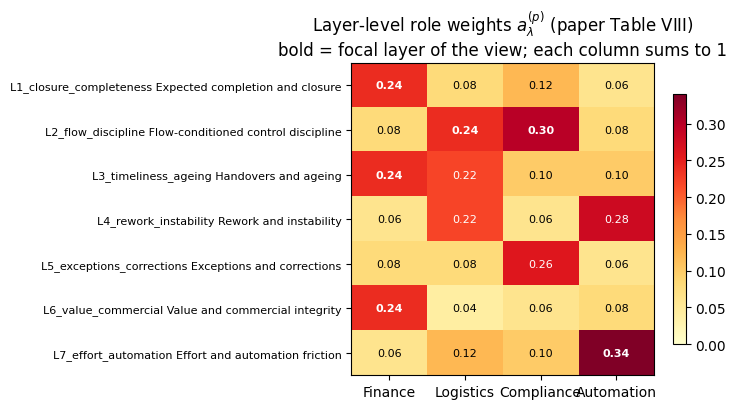

In [30]:
lt = wnorm.layer_weight_table(norm)
print("TABLE VIII — layer weights a_λ^(p) per view (columns sum to 1):")
display(lt.set_index("layer_name").round(2) if "layer_name" in lt.columns else lt.round(2))
viz.fig_layer_weights(lt, name="layer_weights")
print("\nView rationale:")
for v, spec in norm["views"].items():
    print(f"  {v:<10}: {spec.get('why', spec.get('description', '—'))}")
print("\nFull constraint weights w_c^(p) = a·b̂ (first 12 rows):")
display(wnorm.raw_constraint_weights(norm).head(12).round(4))


## 2 — Phase-2 evidence across all views

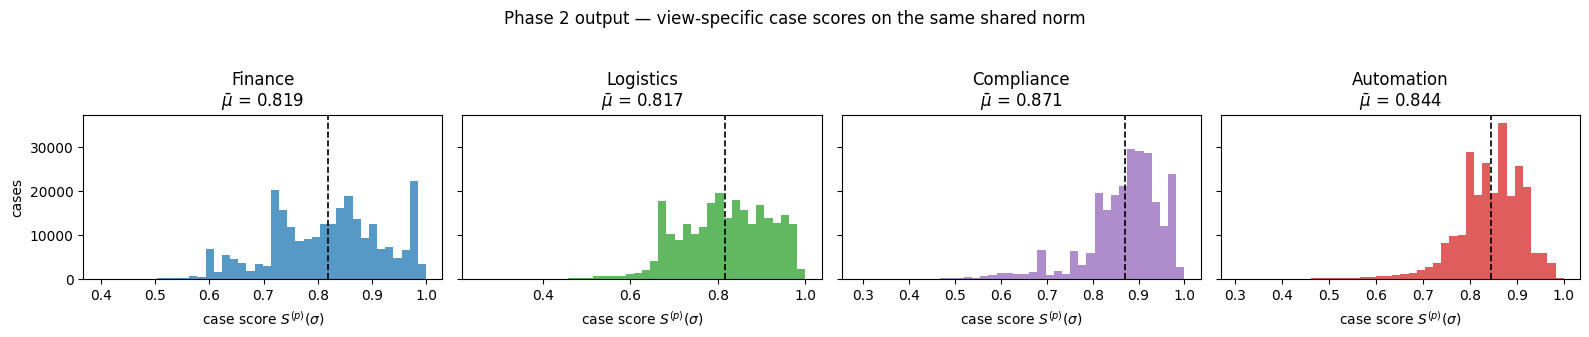

In [31]:
viz.fig_score_distributions(scores, VIEWS, name="score_distributions_all_views");


GLOBAL MECHANISM SIGNALS (view-independent)              [paper, real log]
  1.  22.6% of invoice-bearing items never reach Clear Invoice        [22.6%]  → L1 closure
  2.  88.9% of applicable items show positive IR→CI ageing severity   [68.7%]  → L3 ageing
  3.  10.9% of invoice-bearing items lack invoice evidence            [10.9%]  → L1 completeness
  4.   6.4% of 3-way items lack GR/SES evidence                       [ 6.4%]  → L1 completeness

DOMINANT WEIGHTED LAYER PER VIEW (mean Δλ over all cases)  [paper: L3 for Fin/Log/Compl, L7 for Automation]


,Finance,Logistics,Compliance,Automation
L1_closure_completeness Expected completion and closure,0.0456,0.0188,0.0255,0.0095
L2_flow_discipline Flow-conditioned control discipline,0.0020,0.0059,0.0073,0.0020
L3_timeliness_ageing Handovers and ageing,0.1078,0.1123,0.0541,0.0449
L4_rework_instability Rework and instability,0.0010,0.0041,0.0011,0.0043
L5_exceptions_corrections Exceptions and corrections,0.0019,0.0023,0.0070,0.0013
L6_value_commercial Value and commercial integrity,0.0054,0.0010,0.0015,0.0017
L7_effort_automation Effort and automation friction,0.0173,0.0386,0.0328,0.0920


  Finance    → dominant layer: L3_timeliness_ageing Handovers and ageing
  Logistics  → dominant layer: L3_timeliness_ageing Handovers and ageing
  Compliance → dominant layer: L3_timeliness_ageing Handovers and ageing
  Automation → dominant layer: L7_effort_automation Effort and automation friction


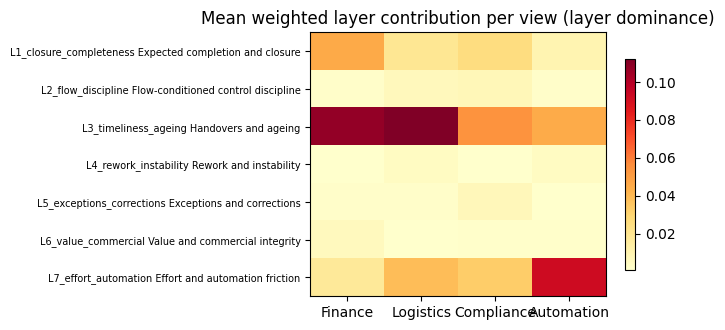

In [32]:
# --- The four view-independent global signals of paper Sec. V-C (Q3.2) ----
def _cnt(col):
    return scores[col].fillna(0) if col in scores.columns else pd.Series(0.0, index=scores.index)

inv_flows  = scores["flow_type"].isin(["DF1", "DF2", "2-way"])      # invoicing expected
three_way  = scores["flow_type"].isin(["DF1", "DF2"])               # GR/SES expected
has_inv    = (_cnt("count__record_invoice_receipt") + _cnt("count__vendor_creates_invoice")) > 0
has_clear  = _cnt("count__clear_invoice") > 0
has_grses  = (_cnt("count__record_goods_receipt") + _cnt("count__record_service_entry_sheet")) > 0

s1 = (inv_flows & ~has_clear).sum() / max(inv_flows.sum(), 1)        # open / missing closure
age_col = next((c for c in scores.columns if "invoice_to_clear" in c and c.startswith("c_")), None)
age = scores[age_col] if age_col else pd.Series(dtype=float)
s2 = (age > 0).sum() / max(age.notna().sum(), 1)                     # positive IR→CI ageing
s3 = (inv_flows & ~has_inv).sum() / max(inv_flows.sum(), 1)          # missing invoice evidence
s4 = (three_way & ~has_grses).sum() / max(three_way.sum(), 1)        # missing GR/SES

print("GLOBAL MECHANISM SIGNALS (view-independent)              [paper, real log]")
print(f"  1. {s1:6.1%} of invoice-bearing items never reach Clear Invoice        [22.6%]  → L1 closure")
print(f"  2. {s2:6.1%} of applicable items show positive IR→CI ageing severity   [68.7%]  → L3 ageing")
print(f"  3. {s3:6.1%} of invoice-bearing items lack invoice evidence            [10.9%]  → L1 completeness")
print(f"  4. {s4:6.1%} of 3-way items lack GR/SES evidence                       [ 6.4%]  → L1 completeness")

print("\nDOMINANT WEIGHTED LAYER PER VIEW (mean Δλ over all cases)  "
      "[paper: L3 for Fin/Log/Compl, L7 for Automation]")
dom_rows = {}
for v in VIEWS:
    m = scores[[f"contrib__{v}__{l}" for l in norm["layers"]]].mean()
    m.index = list(norm["layers"].keys())
    dom_rows[v] = m
layer_dom = pd.DataFrame(dom_rows)
layer_dom.index = [f"{l} {norm['layers'][l]['name']}" for l in layer_dom.index]
display(layer_dom.round(4))
import matplotlib.pyplot as _plt
_fig, _ax = _plt.subplots(figsize=(7,3.4))
_im = _ax.imshow(layer_dom.values, cmap="YlOrRd", aspect="auto")
_ax.set_xticks(range(len(VIEWS)), VIEWS); _ax.set_yticks(range(len(layer_dom)), layer_dom.index, fontsize=7)
_ax.set_title("Mean weighted layer contribution per view (layer dominance)")
_fig.colorbar(_im, ax=_ax, shrink=0.8); _fig.tight_layout()
_fig.savefig(Path(CONFIG["figures_dir"])/"layer_dominance.png", dpi=150, bbox_inches="tight")
for v in VIEWS:
    print(f"  {v:<10} → dominant layer: {layer_dom[v].idxmax()}")


## 3 — Q3.1 for every view: document backlogs and concentration

  Finance   :  2,039 headers =  2.7% capture 80%   |    7,643 = 10.0% capture 95%
  Logistics :  2,110 headers =  2.8% capture 80%   |    7,420 =  9.7% capture 95%
  Compliance:  1,771 headers =  2.3% capture 80%   |    7,012 =  9.2% capture 95%
  Automation:  2,083 headers =  2.7% capture 80%   |    7,722 = 10.1% capture 95%


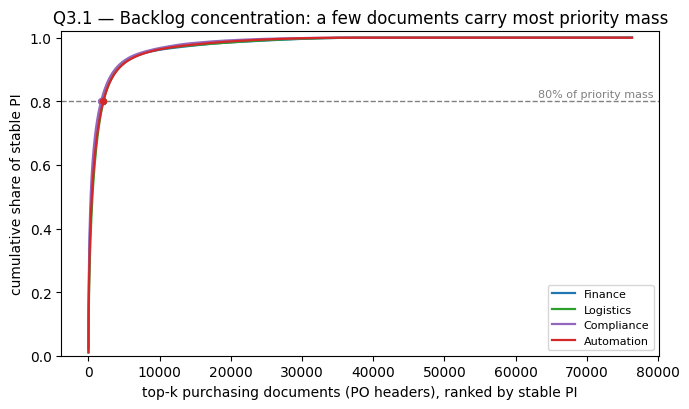

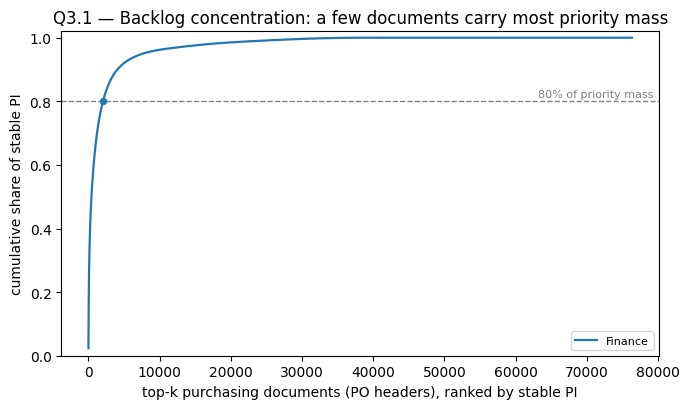

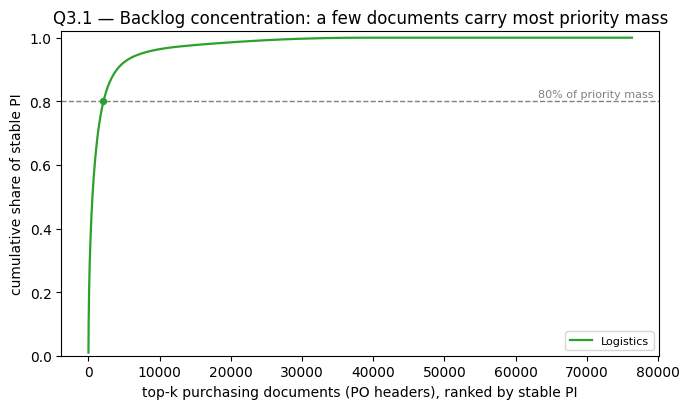

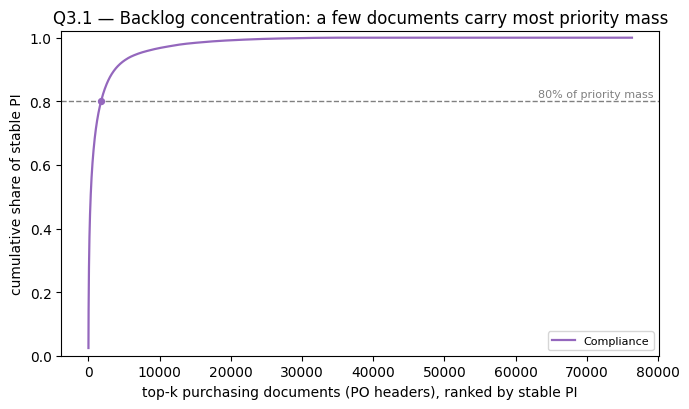

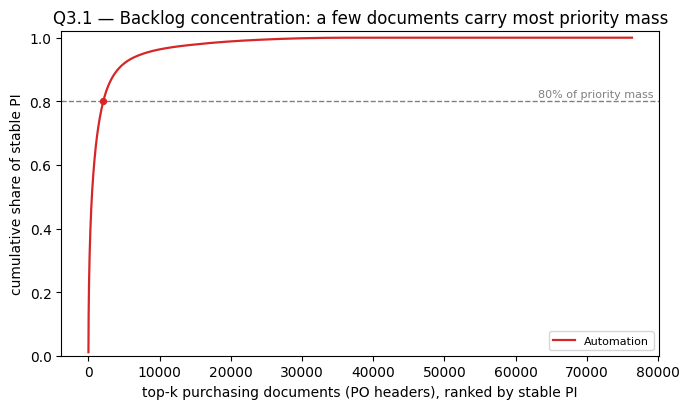

In [33]:
doc_backlogs, doc_cums = {}, {}
for v in VIEWS:
    bl = prio.document_backlog(scores, v)
    conc, cum = prio.pareto_concentration(bl)
    doc_backlogs[v], doc_cums[v] = bl, cum
    (k80, s80), (k95, s95) = conc[0.80], conc[0.95]
    print(f"  {v:<10}: {k80:>6,} headers = {s80:5.1%} capture 80%   |   {k95:>6,} = {s95:5.1%} capture 95%")
viz.fig_document_pareto(doc_cums, name="document_pareto_all_views")
for v in VIEWS:
    viz.fig_document_pareto({v: doc_cums[v]}, name=f"document_pareto_{v.lower()}")


,Finance,Logistics,Compliance,Automation
Finance,1.000,0.143,0.481,0.081
Logistics,0.143,1.000,0.212,0.250
Compliance,0.481,0.212,1.000,0.143
Automation,0.081,0.250,0.143,1.000


,Finance,Logistics,Compliance,Automation
Finance,1.000,0.782,0.817,0.570
Logistics,0.782,1.000,0.767,0.771
Compliance,0.817,0.767,1.000,0.617
Automation,0.570,0.771,0.617,1.000


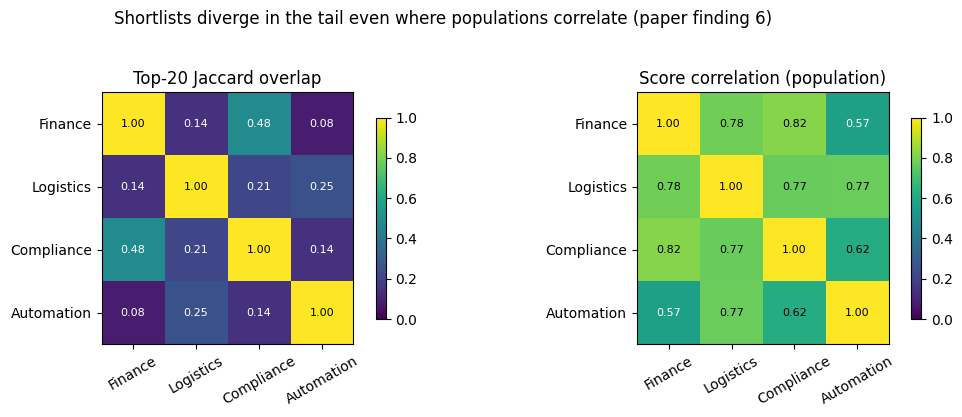

In [34]:
# Cross-view overlap: Jaccard of top-20 shortlists + score correlations
jac = prio.jaccard_topk(doc_backlogs, k=CONFIG["top_k_documents"])
corr = scores[[f"score__{v}" for v in VIEWS]].corr(); corr.index = corr.columns = VIEWS
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, mat, title in [(axes[0], jac.astype(float), f"Top-{CONFIG['top_k_documents']} Jaccard overlap"),
                       (axes[1], corr, "Score correlation (population)")]:
    im = ax.imshow(mat.values, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(VIEWS)), VIEWS, rotation=30); ax.set_yticks(range(len(VIEWS)), VIEWS)
    for i in range(len(VIEWS)):
        for j in range(len(VIEWS)):
            ax.text(j, i, f"{mat.values[i,j]:.2f}", ha="center", va="center",
                    color="white" if mat.values[i,j] < 0.6 else "black", fontsize=8)
    ax.set_title(title); fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle("Shortlists diverge in the tail even where populations correlate (paper finding 6)", y=1.03)
fig.tight_layout(); fig.savefig(Path(CONFIG["figures_dir"])/"view_overlap.png", dpi=150, bbox_inches="tight")
display(jac.round(3)); display(corr.round(3))


## 4 — Q3.1/Q3.2 for every view: slice backlogs, typology, risk matrices

In [35]:
SLICE_KEYS = CONFIG["slice_keys"]
backlogs, typeds = {}, {}
for v in VIEWS:
    backlogs[v] = prio.slice_backlog(scores, v, SLICE_KEYS)
    typeds[v]   = prio.classify_hotspots(backlogs[v], top_n=12)
    print(f"\n=== TOP SLICES — {v} view (stable PI, γ = {CONFIG['shrinkage_gamma']:.0f}) ===")
    display(typeds[v][SLICE_KEYS + ["cases", "slice_mean", "stable_gap", "PI_stable", "hotspot_type"]]
            .head(8).round(4))



=== TOP SLICES — Finance view (stable PI, γ = 20) ===


,case Company,case Spend area text,cases,slice_mean,stable_gap,PI_stable,hotspot_type
0,companyID_0000,Packaging,109199,0.7982,0.0210,2289.2907,reservoir
1,companyID_0000,Logistics,5242,0.7207,0.0981,514.1378,mechanism
2,companyID_0000,(missing),3257,0.7773,0.0415,135.2346,mechanism
3,companyID_0000,Trading & End Products,22292,0.8133,0.0058,129.1904,mechanism
4,companyID_0000,Marketing,1789,0.7905,0.0283,50.6907,mechanism
5,companyID_0000,Additives,18318,0.8164,0.0027,49.9525,mechanism
6,companyID_0003,Real Estate,583,0.7828,0.0351,20.4710,mechanism
7,companyID_0003,Enterprise Services,122,0.7402,0.0678,8.2719,mechanism



=== TOP SLICES — Logistics view (stable PI, γ = 20) ===


,case Company,case Spend area text,cases,slice_mean,stable_gap,PI_stable,hotspot_type
0,companyID_0000,Packaging,109199,0.7944,0.0225,2460.6494,mechanism
1,companyID_0000,Logistics,5242,0.7653,0.0515,270.0081,mechanism
2,companyID_0000,Additives,18318,0.8095,0.0074,135.8756,mechanism
3,companyID_0000,Marketing,1789,0.7790,0.0376,67.2078,mechanism
4,companyID_0000,Latex & Monomers,5007,0.8100,0.0069,34.5260,mechanism
5,companyID_0000,Workforce Services,127,0.6865,0.1127,14.3133,mechanism
6,companyID_0000,(missing),3257,0.8155,0.0015,4.7671,reservoir
7,companyID_0000,Spend Area Unidentified,36,0.6627,0.0992,3.5706,severity



=== TOP SLICES — Compliance view (stable PI, γ = 20) ===


,case Company,case Spend area text,cases,slice_mean,stable_gap,PI_stable,hotspot_type
0,companyID_0000,Packaging,109199,0.8626,0.0081,881.9916,mechanism
1,companyID_0000,Logistics,5242,0.8086,0.0618,323.9355,mechanism
2,companyID_0000,(missing),3257,0.8298,0.0406,132.2794,mechanism
3,companyID_0000,Trading & End Products,22292,0.8652,0.0054,121.2285,reservoir
4,companyID_0000,Marketing,1789,0.8325,0.0377,67.4988,mechanism
5,companyID_0000,Additives,18318,0.8679,0.0028,51.3279,mechanism
6,companyID_0000,Latex & Monomers,5007,0.8608,0.0098,49.0637,mechanism
7,companyID_0000,Workforce Services,127,0.6925,0.1540,19.5524,mechanism



=== TOP SLICES — Automation view (stable PI, γ = 20) ===


,case Company,case Spend area text,cases,slice_mean,stable_gap,PI_stable,hotspot_type
0,companyID_0000,Packaging,109199,0.8357,0.0087,945.7214,reservoir
1,companyID_0000,Logistics,5242,0.7880,0.0561,294.1742,mechanism
2,companyID_0000,Additives,18318,0.8346,0.0097,177.7888,mechanism
3,companyID_0000,Latex & Monomers,5007,0.8265,0.0177,88.8325,mechanism
4,companyID_0003,Real Estate,583,0.7545,0.0869,50.6384,mechanism
5,companyID_0000,(missing),3257,0.8331,0.0111,36.2934,mechanism
6,companyID_0000,Solvents,2629,0.8363,0.0080,20.9424,mechanism
7,companyID_0000,Specialty Resins,2406,0.8389,0.0054,13.1063,mechanism


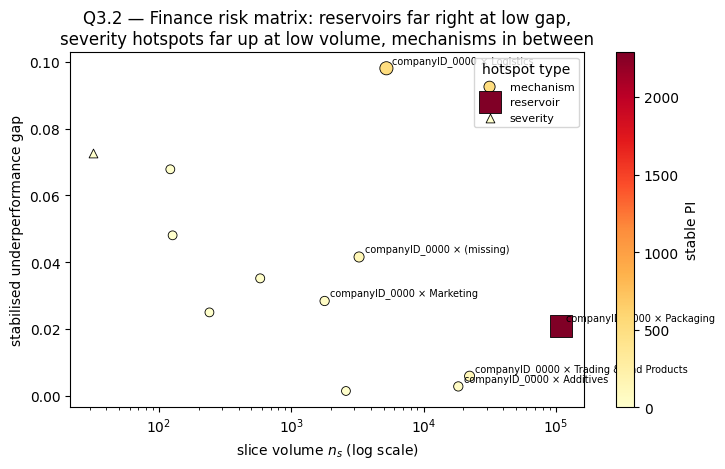

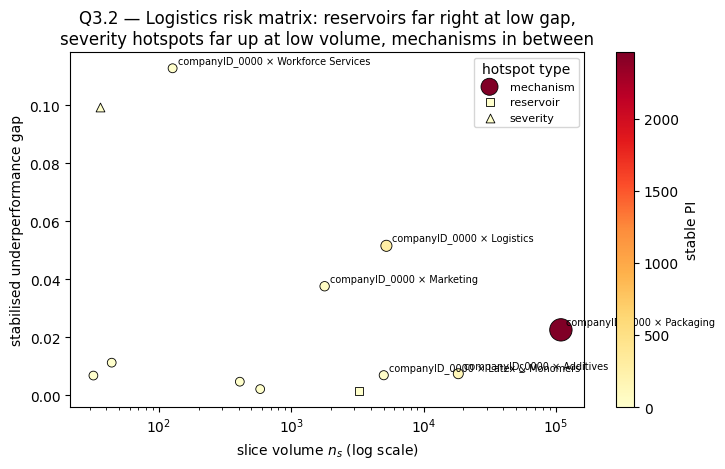

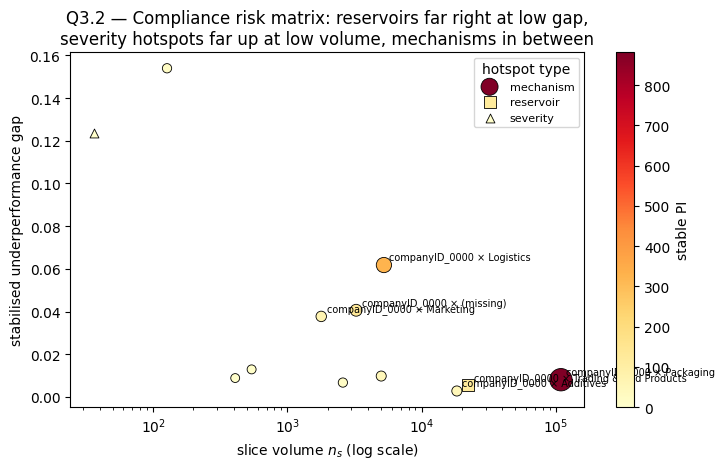

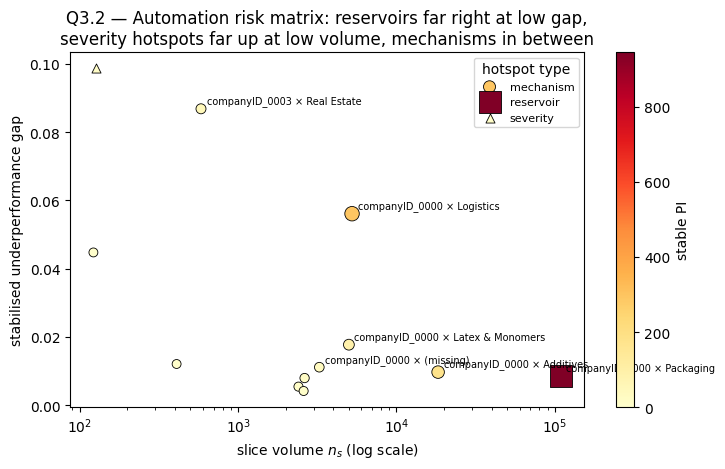

In [36]:
for v in VIEWS:
    viz.fig_risk_matrix(typeds[v], SLICE_KEYS, v, name=f"risk_matrix_{v.lower()}")


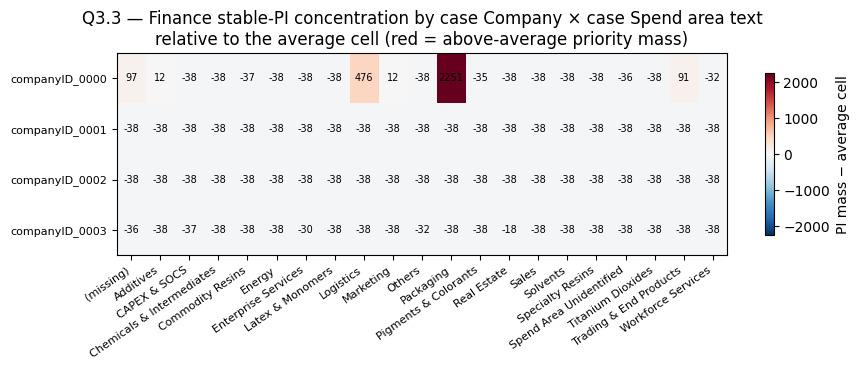

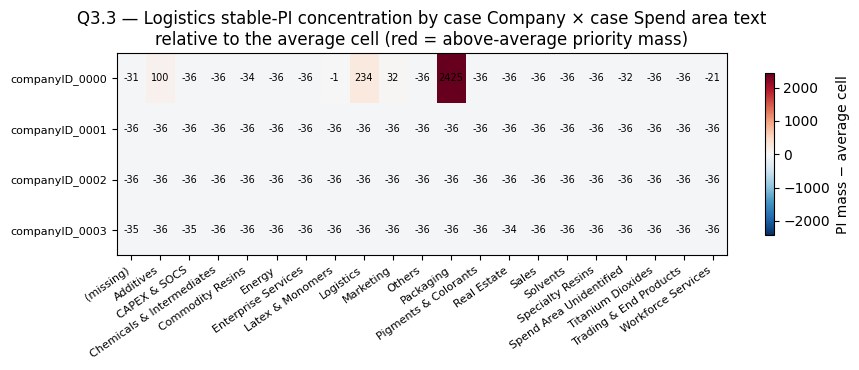

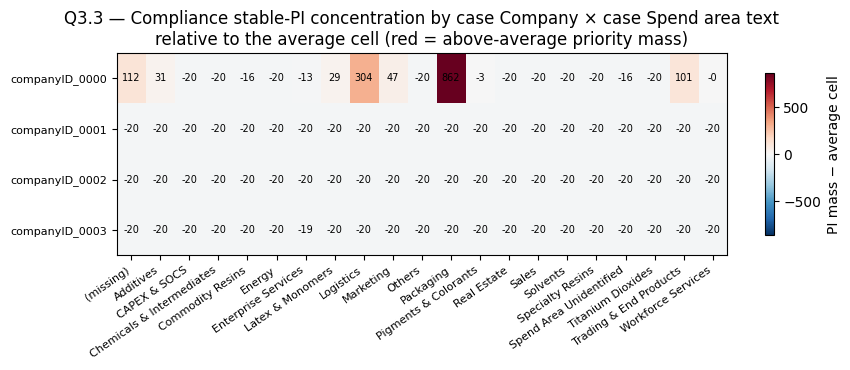

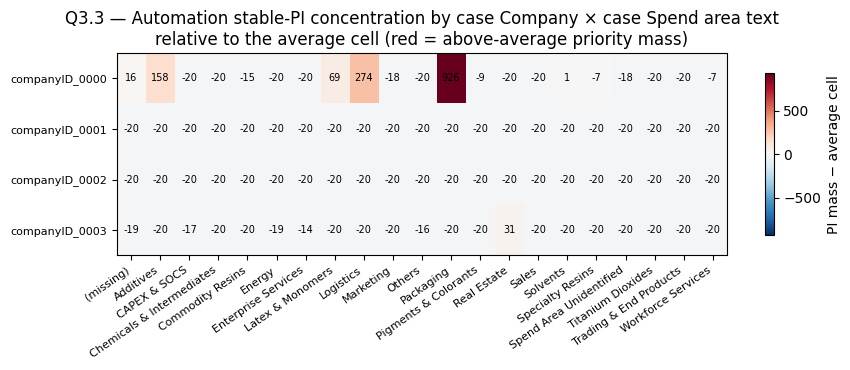

In [37]:
for v in VIEWS:
    viz.fig_ownership_heatmap(backlogs[v], SLICE_KEYS, v, name=f"ownership_heatmap_{v.lower()}")


## 5 — Q3.2 for every view: layer-delta profiles of each view's own top-3 slices

Finance: focus slices = companyID_0000 × Packaging | companyID_0000 × Logistics | companyID_0000 × (missing)
Logistics: focus slices = companyID_0000 × Packaging | companyID_0000 × Logistics | companyID_0000 × Additives
Compliance: focus slices = companyID_0000 × Packaging | companyID_0000 × Logistics | companyID_0000 × (missing)
Automation: focus slices = companyID_0000 × Packaging | companyID_0000 × Logistics | companyID_0000 × Additives


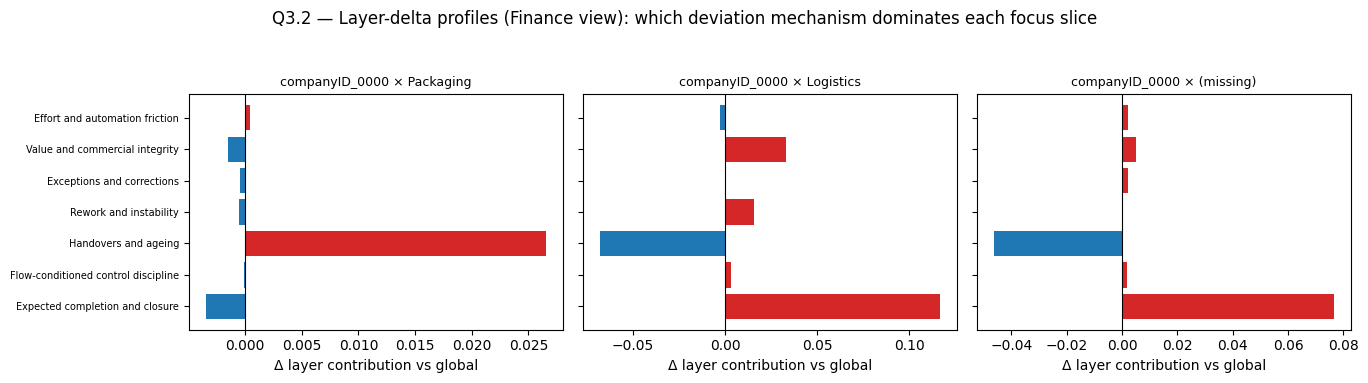

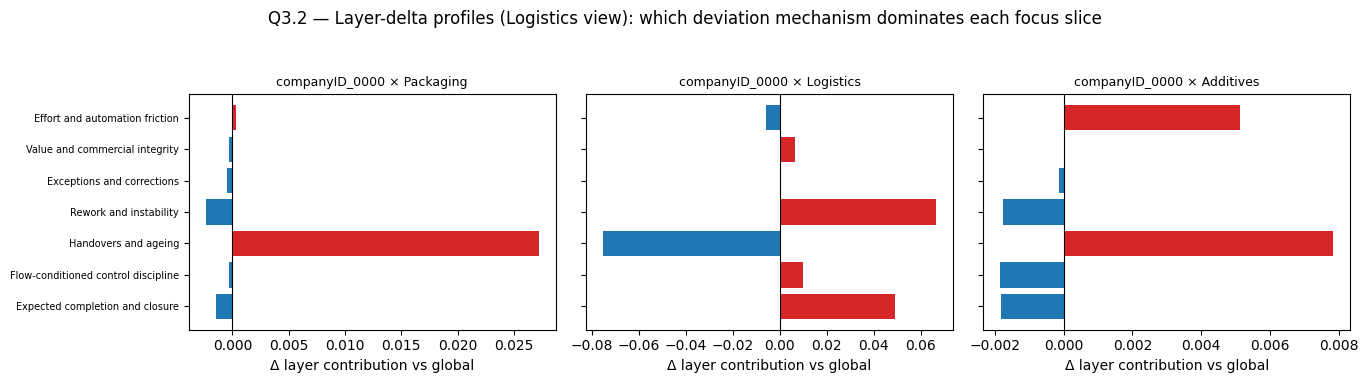

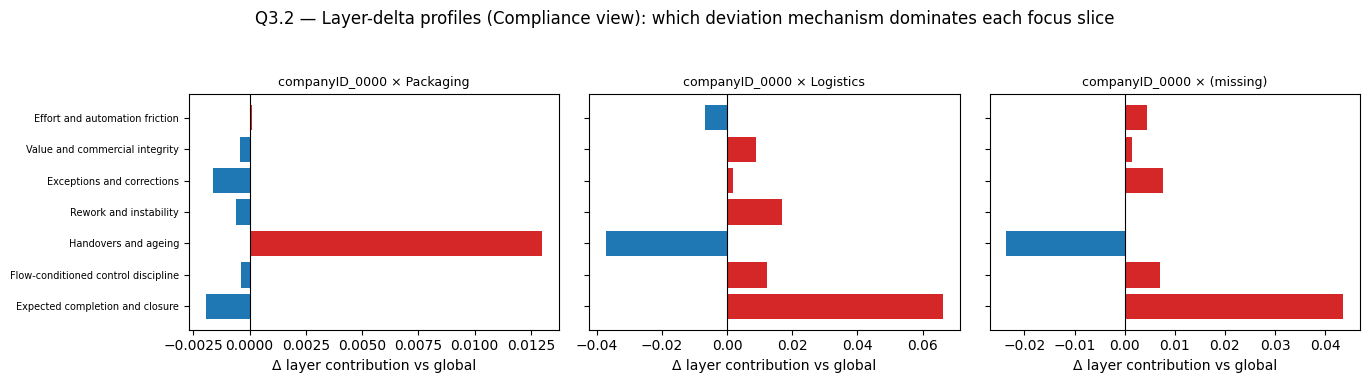

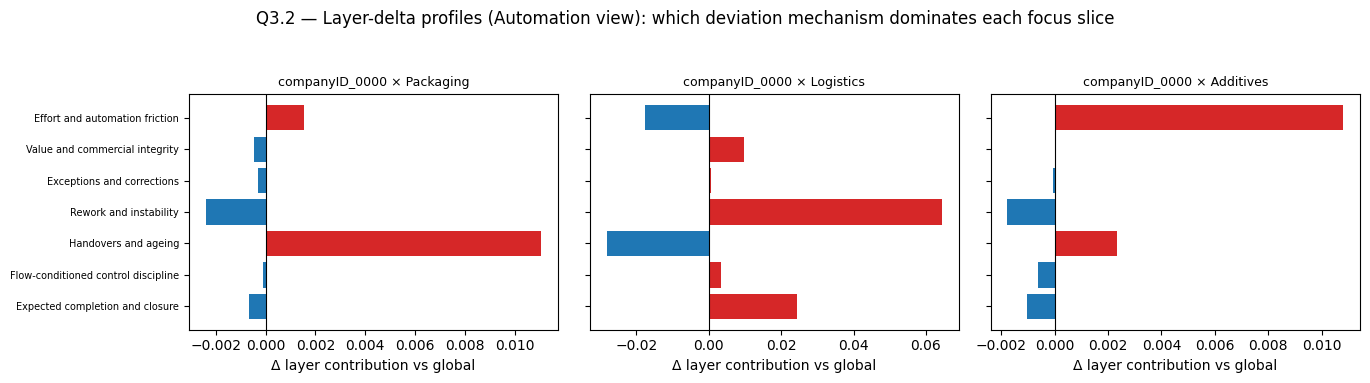

In [38]:
view_focus = {}
for v in VIEWS:
    top3 = [tuple(r[k] for k in SLICE_KEYS) for _, r in typeds[v].head(3).iterrows()]
    view_focus[v] = top3
    deltas = prio.slice_layer_deltas(scores, v, SLICE_KEYS, norm).loc[top3]
    viz.fig_layer_deltas(deltas, norm, v, name=f"layer_deltas_{v.lower()}")
    print(f"{v}: focus slices = " + " | ".join(" × ".join(map(str, s)) for s in top3))


## 6 — Mechanism drill-downs (every focus slice) and Q3.3 vendor Paretos

companyID_0000 × Packaging: median 83d vs 55d (×1.52) → body-wide shift → systemic queue problem (SLA/escalation/workload rebalancing)
companyID_0000 × Logistics: median 68d vs 64d (×1.06) → shift AND heavy tail → both queue management and exception triage
companyID_0000 × Additives: median 71d vs 63d (×1.13) → shift AND heavy tail → both queue management and exception triage


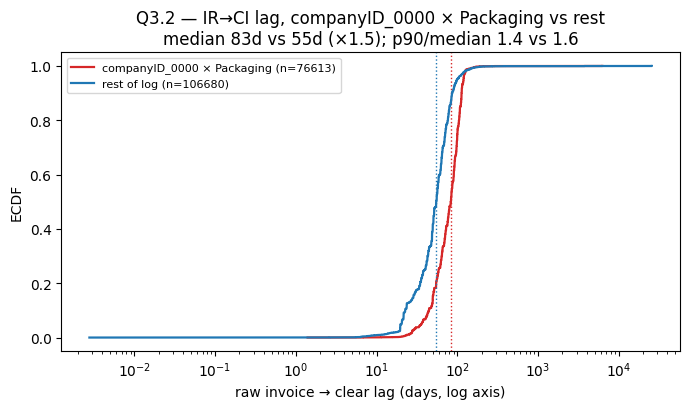

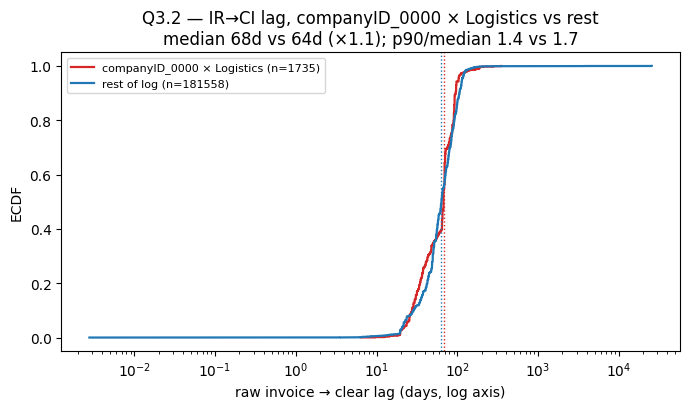

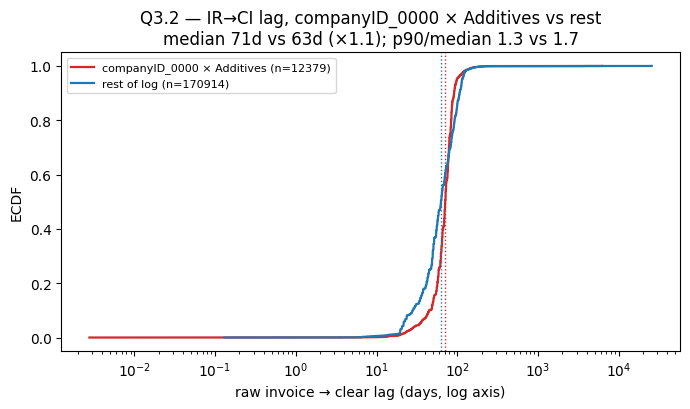

In [39]:
inv_cols = [c for c in ("first_ts__record_invoice_receipt", "first_ts__vendor_creates_invoice")
            if c in scores.columns]
inv_ts = scores[inv_cols].min(axis=1)
lag_days = ((scores.get("first_ts__clear_invoice") - inv_ts).dt.total_seconds() / 86400)
lag_days = lag_days.where(lag_days > 0)
top_auto = view_focus["Automation"]
for sl in top_auto:
    m = (scores[SLICE_KEYS[0]] == sl[0]) & (scores[SLICE_KEYS[1]] == sl[1])
    if lag_days[m].notna().sum() >= 10:
        _, verdict = viz.fig_lag_ecdf(lag_days[m], lag_days[~m], " × ".join(map(str, sl)),
                                      name=f"lag_ecdf_{'_'.join(str(s).lower().replace(' ','') for s in sl)}")
        print(f"{' × '.join(map(str, sl))}: median {verdict['median_in']:.0f}d vs {verdict['median_out']:.0f}d "
              f"(×{verdict['shift_ratio']:.2f}) → {verdict['verdict']}")


Finance    companyID_0000 × Packaging: 19 of 266 vendors carry 80% of penalty
Logistics  companyID_0000 × Packaging: 19 of 266 vendors carry 80% of penalty
Compliance companyID_0000 × Packaging: 20 of 266 vendors carry 80% of penalty
Automation companyID_0000 × Packaging: 22 of 266 vendors carry 80% of penalty


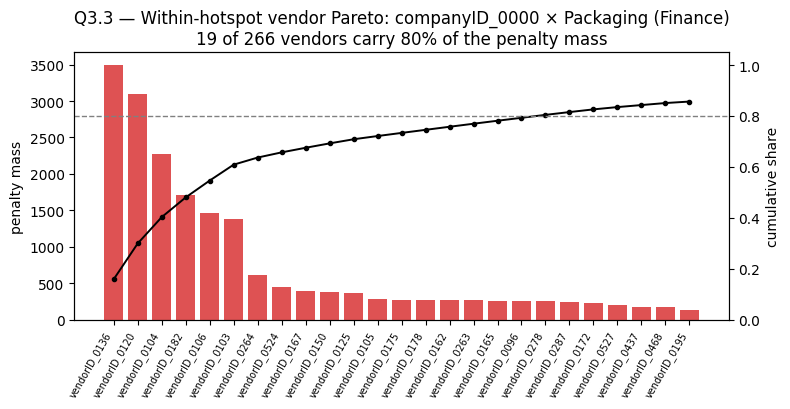

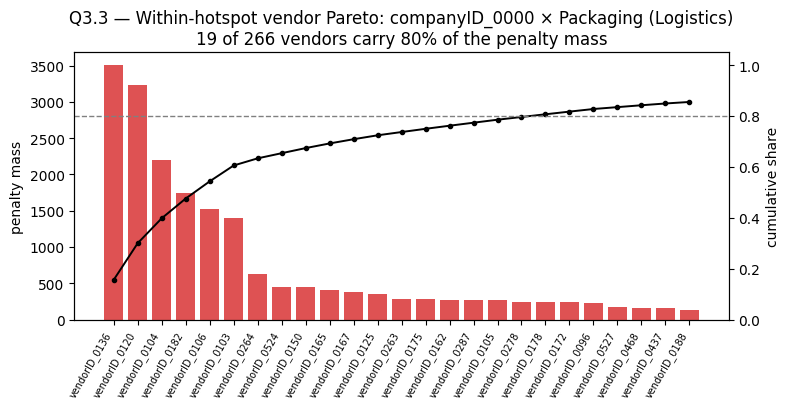

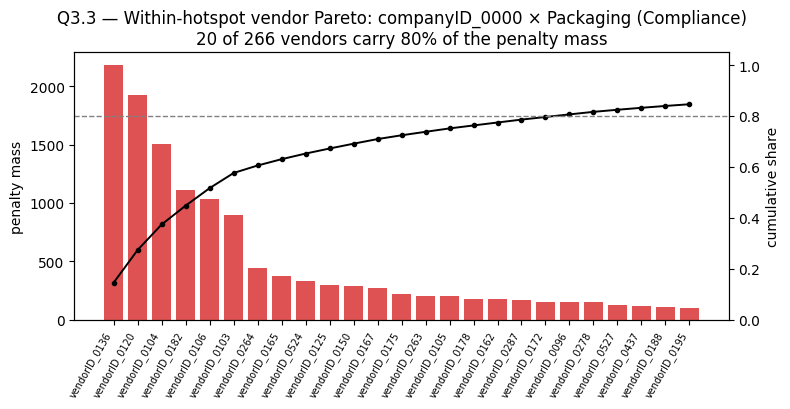

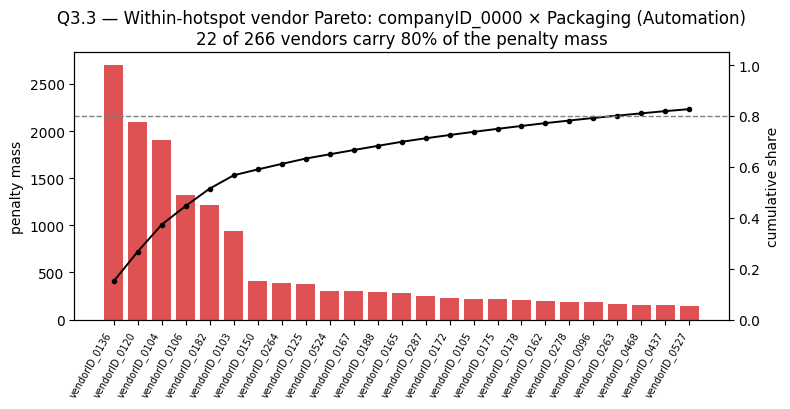

In [40]:
for v in VIEWS:
    sl = view_focus[v][0]
    m = (scores[SLICE_KEYS[0]] == sl[0]) & (scores[SLICE_KEYS[1]] == sl[1])
    pen = (1 - scores.loc[m, f"score__{v}"]).rename("penalty")
    vend = pen.groupby(scores.loc[m, "case Vendor"]).sum().sort_values(ascending=False)
    if len(vend) >= 3:
        _, kk = viz.fig_vendor_pareto(vend, f"{' × '.join(map(str, sl))} ({v})",
                                      name=f"vendor_pareto_{v.lower()}")
        print(f"{v:<10} {' × '.join(map(str, sl))}: {kk['k']} of {kk['K']} vendors carry 80% of penalty")


## 7 — Governance loop for every view: data-quality qualification + quarterly trends

In [41]:
d = gov.add_governance_flags(scores)
print(f"GLOBAL: right-censored {d['is_right_censored'].mean():.1%} of items | "
      f"replicated {d['is_replicated'].mean():.1%} | open invoices {d['is_open_invoice'].mean():.1%}")
print("\nTABLE X (extended) — top-5 Automation slices:")
top5 = [tuple(r[k] for k in SLICE_KEYS) for _, r in typeds["Automation"].head(5).iterrows()]
display(gov.governance_table(d, "Automation", top5, SLICE_KEYS).round(3))


GLOBAL: right-censored 0.0% of items | replicated 1.7% | open invoices 11.2%

TABLE X (extended) — top-5 Automation slices:


,focus_slice,cases,right_censored_share,replicated_event_share,stable_gap_all,stable_gap_excl_censored,gap_retained_excl_censored,reading
0,companyID_0000 × Packaging,109199,0.0,0.000,0.009,0.009,1.0,gap largely retained → hotspot is not a window...
1,companyID_0000 × Logistics,5242,0.0,0.725,0.056,0.056,1.0,gap largely retained → hotspot is not a window...
2,companyID_0000 × Additives,18318,0.0,0.000,0.010,0.010,1.0,gap largely retained → hotspot is not a window...
3,companyID_0000 × Latex & Monomers,5007,0.0,0.000,0.018,0.018,1.0,gap largely retained → hotspot is not a window...
4,companyID_0003 × Real Estate,583,0.0,0.000,0.087,0.087,1.0,gap largely retained → hotspot is not a window...


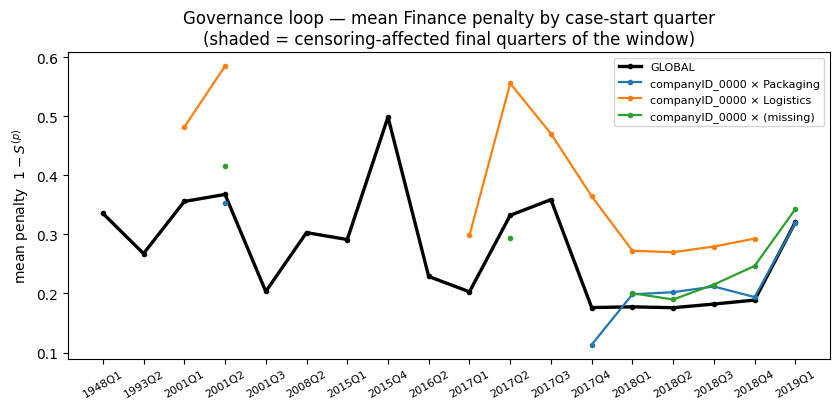

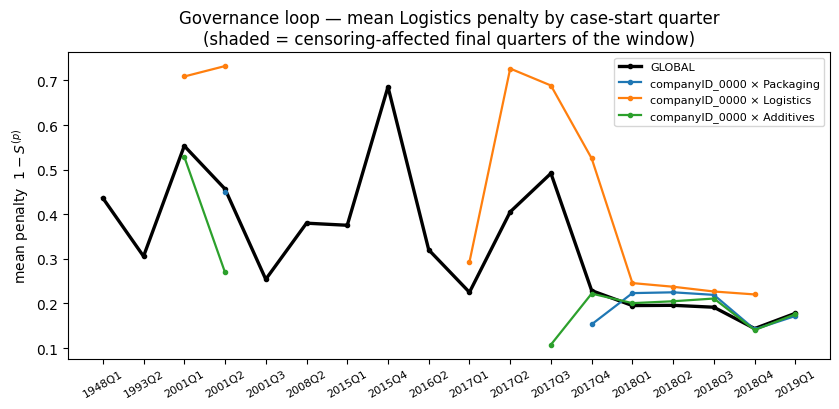

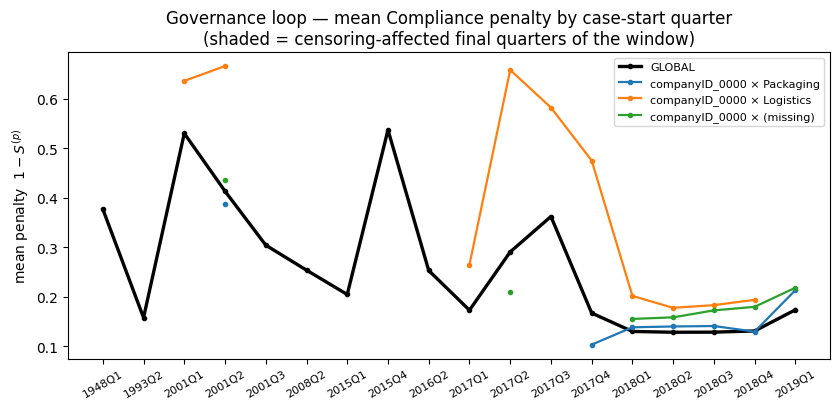

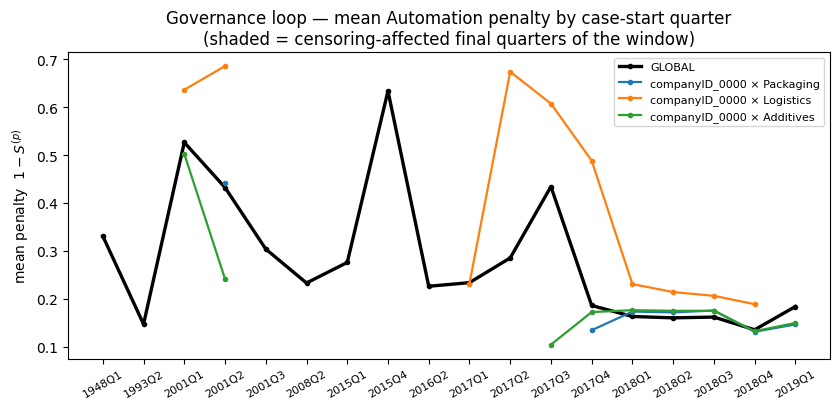

In [42]:
window_end = d["_window_end"].iloc[0]
horizon = window_end - pd.Timedelta(days=CONFIG["censoring_window_days"])
for v in VIEWS:
    trend = gov.quarterly_penalty_trend(d, v, view_focus[v], SLICE_KEYS)
    censor_q = [q for q in trend.index if pd.Period(q).end_time >= horizon]
    viz.fig_quarterly_trend(trend, censor_q, v, name=f"quarterly_trend_{v.lower()}")


## 8 — Root-cause & explanatory analysis (beyond WISE prioritisation)

WISE tells us **where** deviation concentrates and **which layer** dominates a
slice. This section adds the next analytical step (the paper's *Future Work:
stronger links to root-cause analysis*) with eight complementary methods, all
descriptive — no causal claims. We drill into each view's **top hotspot**.

| Method | Question it answers | Figure |
|---|---|---|
| Constraint prevalence | which individual checks carry the penalty, not just which layer | bar |
| Constraint co-occurrence (lift) | which deviations travel together → shared mechanism | heatmap |
| Contrastive drivers (Cohen's d) | what measurably separates the hotspot from the rest of the log | diverging bar |
| Surrogate decision tree | human-readable threshold rules for a low score | text rules |
| Permutation importance | model-agnostic global drivers of the score | bar |
| Resource hand-off matrix | coordination overhead / segregation-of-duties surface | heatmap |
| Variant severity | which concrete execution sequences are worst | table |
| Value-phase profile | is the deviation in the financially material high-value tail? | bar |


In [43]:
from wise_eval import explain as ex

# One representative hotspot per view = each view's own #1 slice (Section 4).
RC_TARGETS = {v: view_focus[v][0] for v in VIEWS}
print("Root-cause targets (top slice per view):")
for v, sl in RC_TARGETS.items():
    print(f"  {v:<10} → {' × '.join(map(str, sl))}")

# Default deep-dive view = Automation (rework/effort lens, matches paper drill-down)
RC_VIEW = "Automation"
RC_SLICE = RC_TARGETS[RC_VIEW]
rc_mask = ex._slice_mask(scores, SLICE_KEYS, RC_SLICE)
rc_label = " × ".join(map(str, RC_SLICE))
print(f"\nDeep dive: {rc_label}  ({RC_VIEW} view, n = {int(rc_mask.sum()):,} items)")


Root-cause targets (top slice per view):
  Finance    → companyID_0000 × Packaging
  Logistics  → companyID_0000 × Packaging
  Compliance → companyID_0000 × Packaging
  Automation → companyID_0000 × Packaging

Deep dive: companyID_0000 × Packaging  (Automation view, n = 109,199 items)


### 8.1 Constraint prevalence — which checks (not just layers) carry the penalty
Layer deltas show L4 dominates Logistics; this resolves it to the exact
constraint. Global vs in-slice side by side shows what is *specific* to the hotspot.


GLOBAL — top constraints by penalty mass:


,constraint,layer,fire_rate,mean_severity,penalty_mass
0,c_l3_df2_rpb_to_clear_days,L3_timeliness_ageing,0.158,0.671,0.671
1,c_l3_df2_goods_to_rpb_days,L3_timeliness_ageing,0.155,0.658,0.658
2,c_l3_invoice_to_clear_days,L3_timeliness_ageing,0.647,0.559,0.559
3,c_l7_manual_share,L7_effort_automation,0.921,0.536,0.536
4,c_l2_df1_invoice_after_goods,L2_flow_discipline,0.023,0.517,0.517
5,c_l7_distinct_human_resources,L7_effort_automation,0.832,0.442,0.442
6,c_l3_df1_goods_to_invoice_days,L3_timeliness_ageing,0.008,0.228,0.228
7,c_l1_clear_invoice_present,L1_closure_completeness,0.213,0.226,0.226



companyID_0000 × Packaging — top constraints by penalty mass:


,constraint,layer,fire_rate,mean_severity,penalty_mass
0,c_l3_df2_rpb_to_clear_days,L3_timeliness_ageing,0.186,0.752,0.752
1,c_l3_invoice_to_clear_days,L3_timeliness_ageing,0.678,0.731,0.731
2,c_l3_df2_goods_to_rpb_days,L3_timeliness_ageing,0.204,0.713,0.713
3,c_l2_df1_invoice_after_goods,L2_flow_discipline,0.021,0.586,0.586
4,c_l7_manual_share,L7_effort_automation,0.925,0.551,0.551
5,c_l7_distinct_human_resources,L7_effort_automation,0.846,0.464,0.464
6,c_l1_clear_invoice_present,L1_closure_completeness,0.220,0.238,0.238
7,c_l3_df1_goods_to_invoice_days,L3_timeliness_ageing,0.003,0.096,0.096


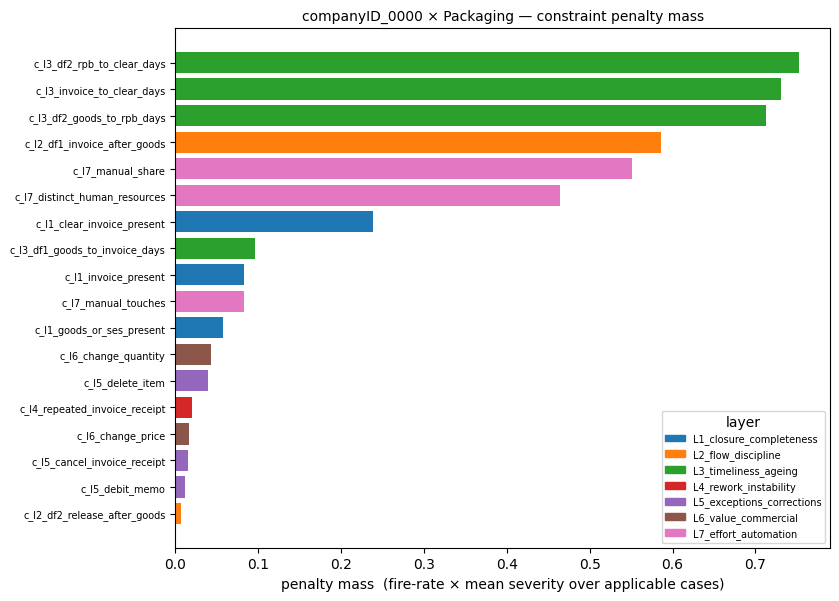

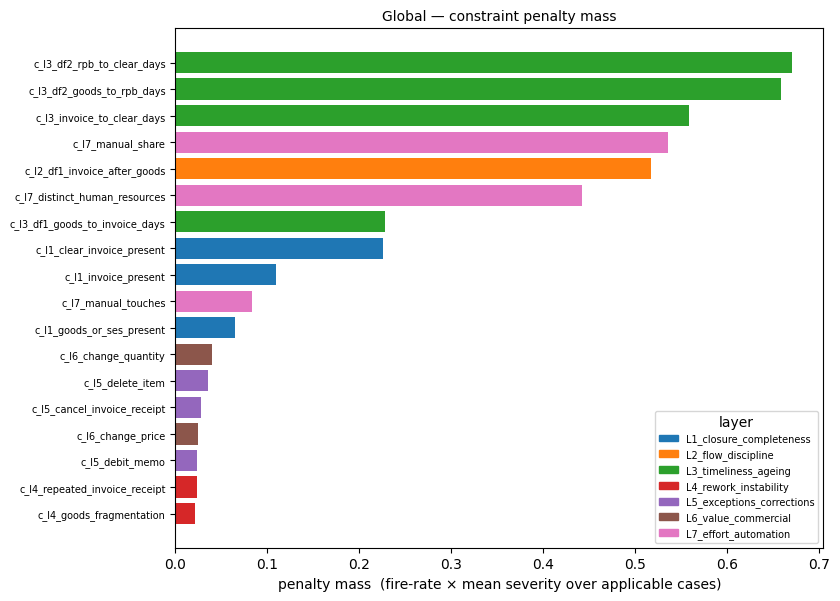

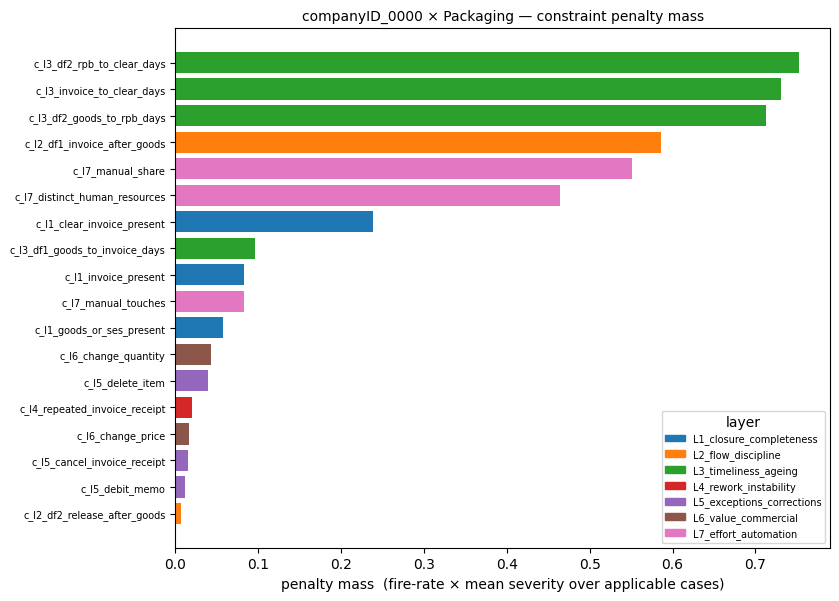

In [44]:
prev_global = ex.constraint_prevalence(scores, norm, mask=None)
prev_slice  = ex.constraint_prevalence(scores, norm, mask=rc_mask)
print("GLOBAL — top constraints by penalty mass:")
display(prev_global.head(8)[["constraint","layer","fire_rate","mean_severity","penalty_mass"]].round(3))
print(f"\n{rc_label} — top constraints by penalty mass:")
display(prev_slice.head(8)[["constraint","layer","fire_rate","mean_severity","penalty_mass"]].round(3))
viz.fig_constraint_prevalence(prev_global, "Global — constraint penalty mass", "rc_prevalence_global")
viz.fig_constraint_prevalence(prev_slice, f"{rc_label} — constraint penalty mass", "rc_prevalence_slice")


### 8.2 Constraint co-occurrence — which deviations travel together
High **lift** between two constraints means they fire together far more than
chance: a structural hint they share one underlying mechanism (e.g. fragmentation
co-occurring with late clearing → a receiving problem that delays settlement).


companyID_0000 × Packaging — constraint pairs that co-occur most (top lift):


,constraint_a,constraint_b,support_both,jaccard,lift
0,c_l6_change_price,c_l6_high_exposure_price_change,3515,1.00,31.05
1,c_l1_goods_or_ses_present,c_l5_delete_item,3867,0.62,16.85
2,c_l1_invoice_present,c_l1_goods_or_ses_present,5738,0.68,12.87
3,c_l1_invoice_present,c_l5_delete_item,3891,0.44,11.82
4,c_l1_invoice_present,c_l1_clear_invoice_present,8324,0.35,4.54
5,c_l1_clear_invoice_present,c_l1_goods_or_ses_present,5745,0.24,4.49
6,c_l1_clear_invoice_present,c_l5_delete_item,3917,0.16,4.14
7,c_l3_df2_goods_to_rpb_days,c_l3_df2_rpb_to_clear_days,15368,0.56,3.71
8,c_l4_repeated_invoice_receipt,c_l7_manual_touches,3418,0.10,3.00
9,c_l6_high_exposure_price_change,c_l7_manual_touches,2965,0.08,2.66


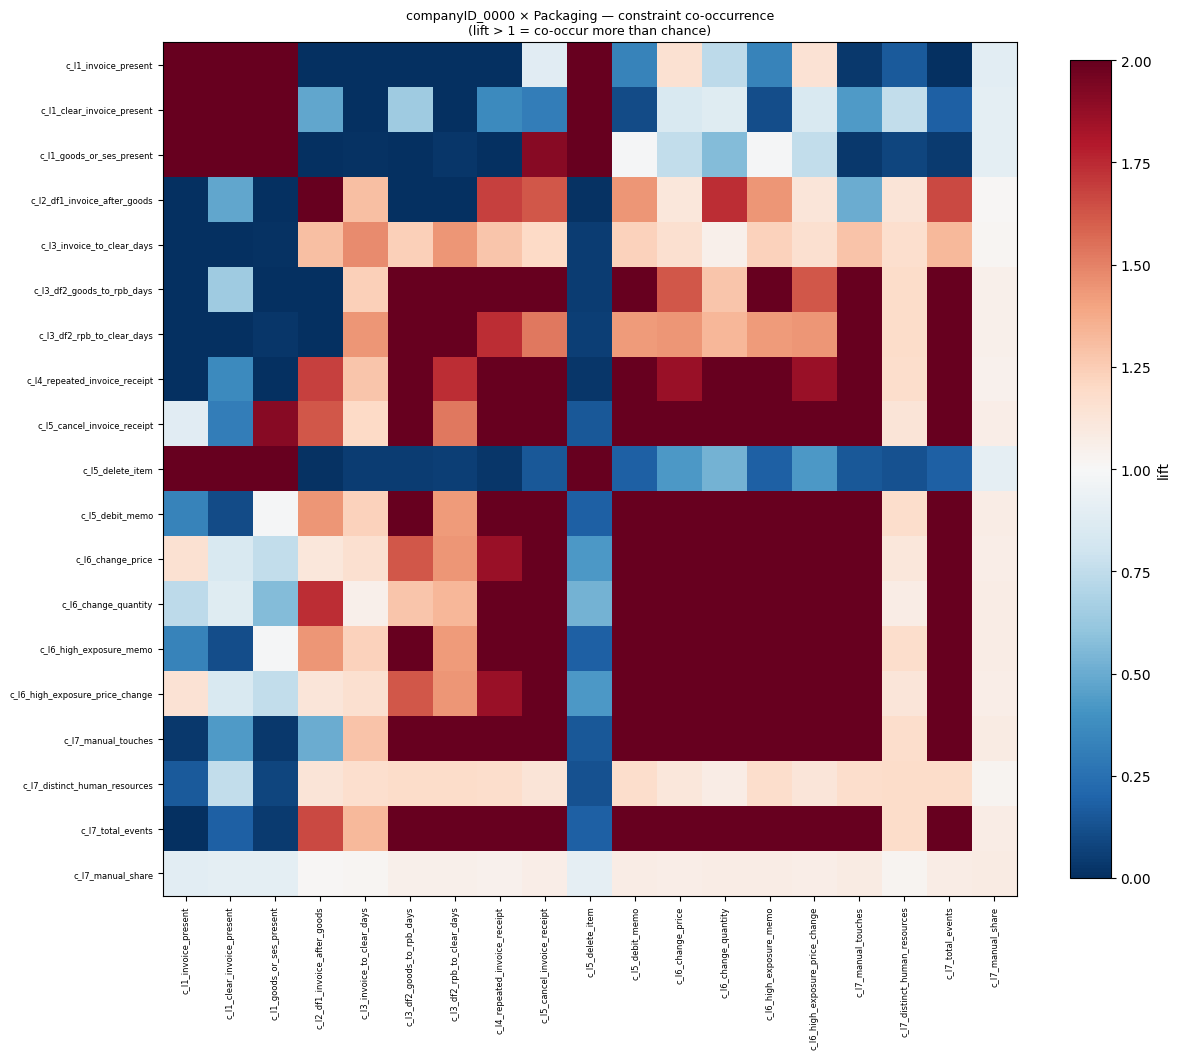

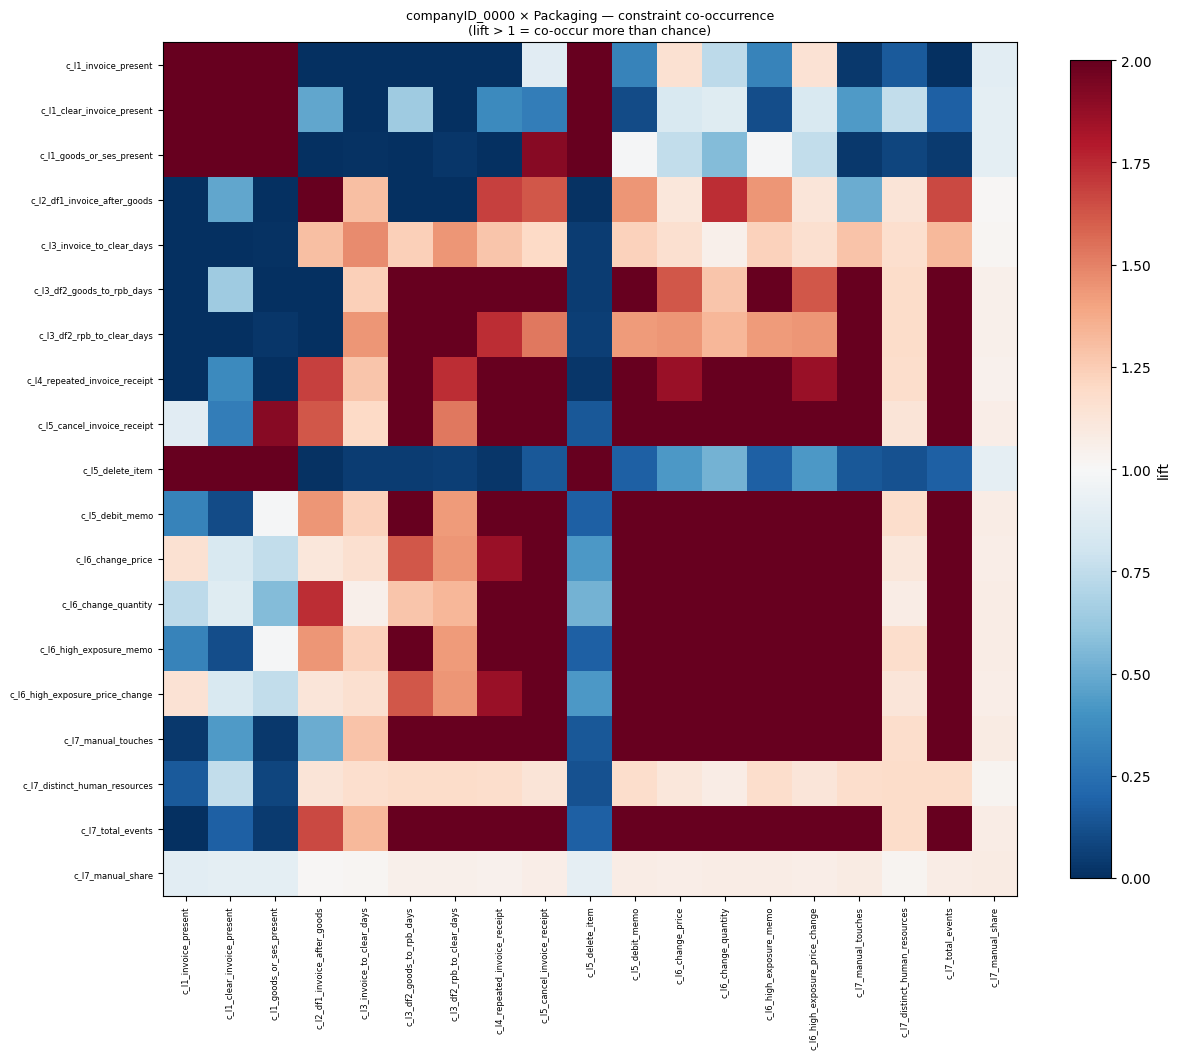

In [45]:
co = ex.constraint_cooccurrence(scores, norm, rc_mask, min_support=max(20, int(rc_mask.sum()*0.02)))
print(f"{rc_label} — constraint pairs that co-occur most (top lift):")
display(co.head(10).round(2))
viz.fig_cooccurrence_heatmap(scores, norm, rc_mask, f"{rc_label} — constraint co-occurrence", "rc_cooccurrence")


### 8.3 Contrastive drivers — what separates the hotspot from the rest
Standardized mean difference (Cohen's d) of every feature and constraint,
in-slice vs rest-of-log. This is the core contrastive root-cause view: the bars
at the top are *what makes this slice different*. |d|>0.8 is a large effect.


,feature,in_mean,rest_mean,cohens_d
0,c_l3_invoice_to_clear_days,0.731,0.435,0.926
1,count__receive_order_confirmation,0.230,0.049,0.562
2,c_l3_df1_goods_to_invoice_days,0.096,0.286,-0.540
3,exposure_norm,0.075,0.184,-0.447
4,c_l3_df2_rpb_to_clear_days,0.752,0.589,0.405
5,c_l3_df2_goods_to_rpb_days,0.713,0.598,0.260
6,c_l4_goods_fragmentation,0.003,0.036,-0.235
7,c_l7_total_events,0.002,0.027,-0.228
8,c_l2_df1_invoice_after_goods,0.586,0.479,0.215
9,c_l6_bal_networth_volatility,0.000,0.025,-0.214


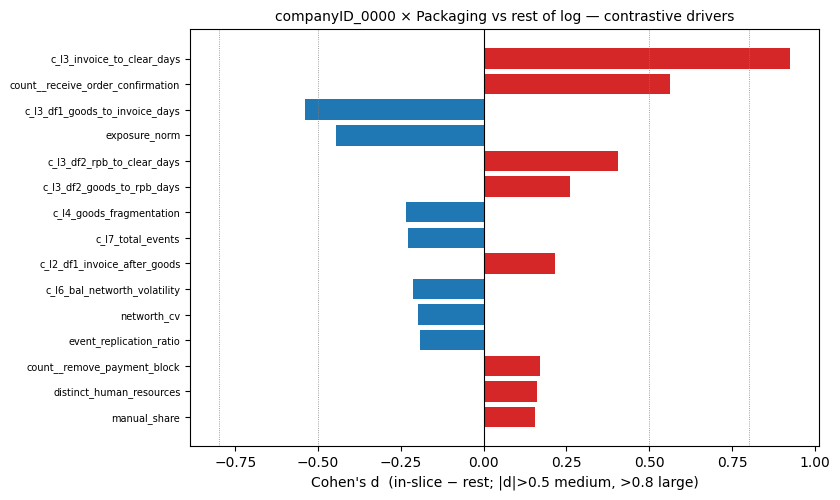

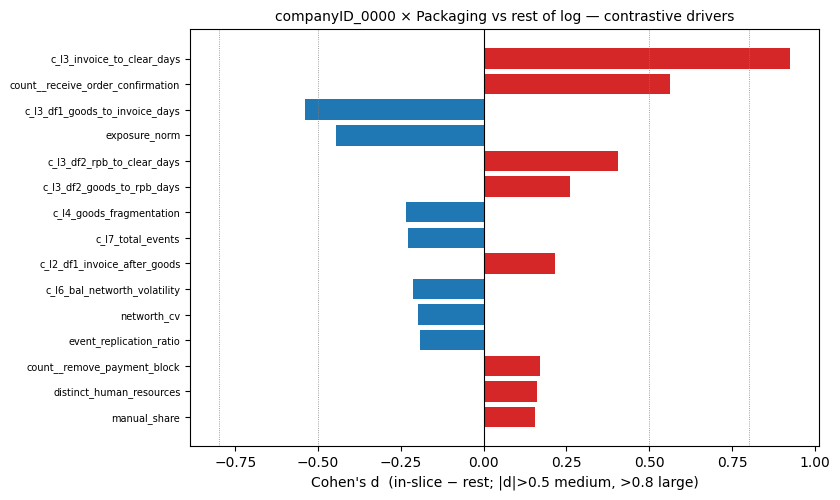

In [46]:
con = ex.contrastive_drivers(scores, norm, rc_mask, top=15)
display(con[["feature","in_mean","rest_mean","cohens_d"]].round(3))
viz.fig_contrastive_drivers(con, f"{rc_label} vs rest of log — contrastive drivers", "rc_contrastive")


### 8.4 Surrogate decision tree + permutation importance — readable score drivers
A shallow tree approximates "what makes a case a low scorer" with a handful of
thresholds (intrinsic interpretability), and permutation importance gives the
model-agnostic global ranking (the paper's XAI angle: LIME/SHAP family).


Surrogate rules for a bottom-10% Automation score (whole log):

|--- total_events <= 6.50
|   |--- manual_touch_count <= 4.50
|   |   |--- count__change_approval_for_purchase_order <= 0.50
|   |   |   |--- class: 0
|   |   |--- count__change_approval_for_purchase_order >  0.50
|   |   |   |--- class: 1
|   |--- manual_touch_count >  4.50
|   |   |--- count__receive_order_confirmation <= 0.50
|   |   |   |--- class: 0
|   |   |--- count__receive_order_confirmation >  0.50
|   |   |   |--- class: 1
|--- total_events >  6.50
|   |--- manual_touch_count <= 5.50
|   |   |--- total_events <= 21.50
|   |   |   |--- class: 0
|   |   |--- total_events >  21.50
|   |   |   |--- class: 1
|   |--- manual_touch_count >  5.50
|   |   |--- manual_touch_count <= 6.50
|   |   |   |--- class: 1
|   |   |--- manual_touch_count >  6.50
|   |   |   |--- class: 1


Permutation importance (surrogate R² = 0.80):


,feature,importance,std
0,total_events,0.4160,0.0070
1,distinct_human_resources,0.3881,0.0100
2,manual_share,0.2837,0.0059
3,exposure_norm,0.0439,0.0011
4,count__clear_invoice,0.0292,0.0015
5,count__remove_payment_block,0.0155,0.0010
6,count__record_invoice_receipt,0.0152,0.0007
7,count__record_goods_receipt,0.0142,0.0010
8,count__change_approval_for_purchase_order,0.0139,0.0005
9,count__create_purchase_requisition_item,0.0137,0.0003


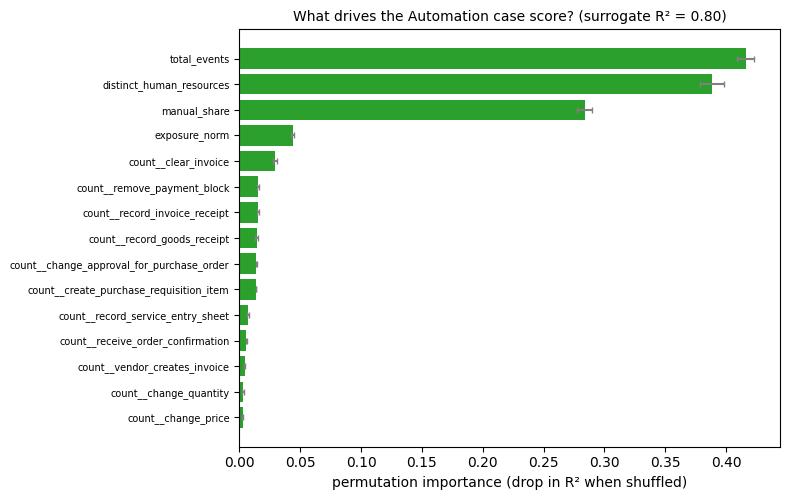

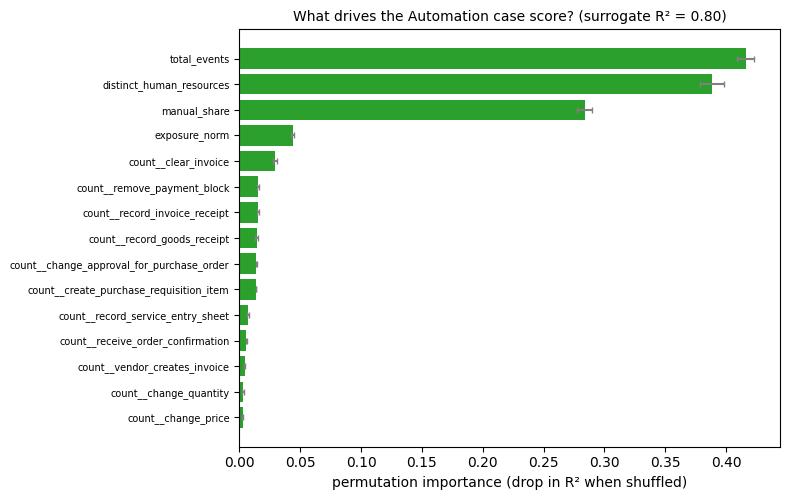

In [47]:
clf, rules, fcols = ex.surrogate_tree_rules(scores, RC_VIEW, max_depth=3, low_quantile=0.10)
print(f"Surrogate rules for a bottom-10% {RC_VIEW} score (whole log):\n")
print(rules)
imp, r2 = ex.permutation_importance_for_score(scores, RC_VIEW, sample=20000, n_repeats=5)
print(f"\nPermutation importance (surrogate R² = {r2:.2f}):")
display(imp.head(10).round(4))
viz.fig_permutation_importance(imp, r2, RC_VIEW, "rc_permutation_importance")


### 8.5 Resource hand-off matrix — coordination overhead & SoD surface
Consecutive same-case events by **different** resources are hand-offs. A dense
off-diagonal means many human hand-offs (coordination cost; also the
segregation-of-duties surface the paper flags as a future drill-down).


companyID_0000 × Packaging — top resource→resource hand-offs (count):


,NONE,user_001,user_002,user_006,user_012,user_013,user_015,user_019,user_020,user_029,user_030,user_057,user_235
NONE,0,4888,420,395,5925,4926,265,7165,13067,32,3258,107,16075
user_001,166,0,4746,652,20,37,1147,5,21,1,0,10,7
user_002,68,86,0,15,21,50,220,25,21,0,0,0,14
user_006,91,28,7928,0,8,12,24,8,18,0,0,10,0
user_012,187,20,6743,874,0,52,380,25,9,0,19,5,4
user_013,292,31,4573,457,57,0,1219,35,14,0,4,2,7
user_015,377,53,7619,23,23,35,0,12,21,0,1,5,34
user_019,386,22,6977,568,20,24,827,0,70,0,24,8,7
user_020,407,21,11325,1484,12,36,1214,93,0,4,28,16,8
user_029,4921,6,5,1,3,7,0,8,14,0,5080,16,7


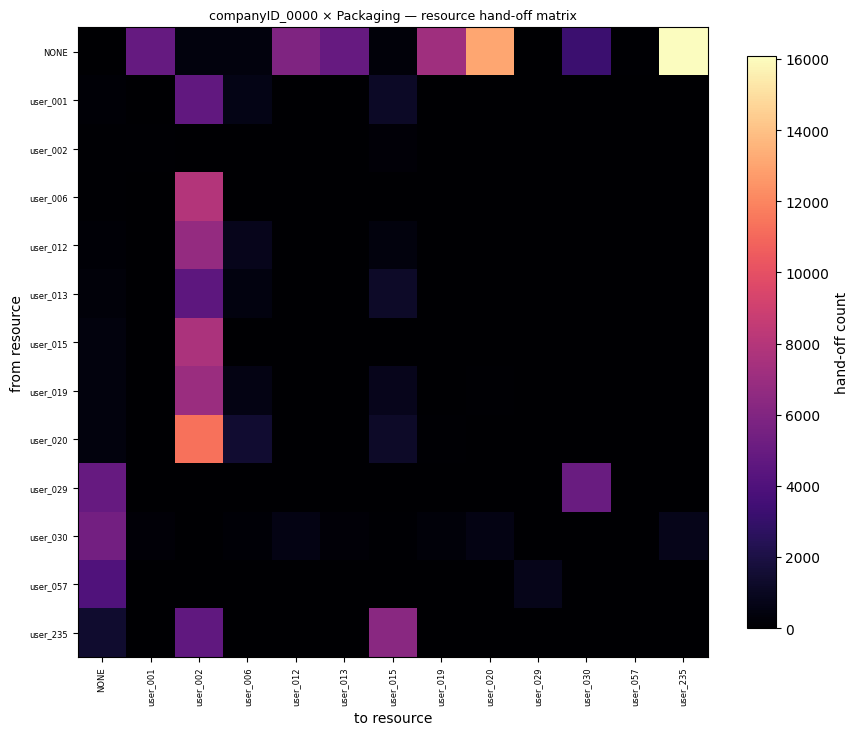

In [48]:
H = ex.resource_handoff_matrix(df, scores.loc[rc_mask, "case_id"], top_resources=12)
print(f"{rc_label} — top resource→resource hand-offs (count):")
display(H)
if H.values.sum() > 0:
    viz.fig_handoff_matrix(H, f"{rc_label} — resource hand-off matrix", "rc_handoff")


### 8.6 Variant severity — which concrete behaviours are worst
Links the abstract PI hotspot back to real execution sequences: the trace
variants inside the slice ranked by total penalty mass. These are the patterns a
workshop would actually look at.


In [49]:
vt = ex.variant_severity_table(df, scores, RC_VIEW, rc_mask, top=12)
print(f"{rc_label} — worst trace variants by penalty mass:")
display(vt.round(3))


companyID_0000 × Packaging — worst trace variants by penalty mass:


,variant,cases,mean_penalty,penalty_mass
0,Create Purchase Order Item → Record Goods Rece...,18214,0.158,2884.619
1,Create Purchase Order Item → Vendor creates in...,12293,0.164,2010.414
2,Create Purchase Order Item → Receive Order Con...,9385,0.178,1667.333
3,Create Purchase Order Item → Record Goods Rece...,6076,0.187,1135.052
4,Create Purchase Order Item → Vendor creates in...,5416,0.189,1021.859
5,Create Purchase Order Item → Record Goods Receipt,7234,0.090,648.857
6,Create Purchase Order Item → Vendor creates in...,4077,0.159,648.454
7,Create Purchase Order Item → Receive Order Con...,2620,0.164,429.329
8,Create Purchase Order Item → Receive Order Con...,1661,0.232,384.916
9,Create Purchase Order Item → Delete Purchase O...,2419,0.150,363.255


### 8.7 Value-phase profile — is the deviation financially material?
Splits the slice into exposure (value) bands and shows where penalty mass sits.
Deviation concentrated in the high-value tail (Q5) is materially different from
the same rate spread over low-value noise — the conservative Q3.3 value reading.


,value_band,cases,mean_penalty,total_exposure,penalty_mass,penalty_mass_share
0,Q1,21840,0.130,54.299,2848.469,0.159
1,Q2,21840,0.162,252.393,3535.165,0.197
2,Q3,21839,0.167,561.771,3654.997,0.204
3,Q4,21840,0.171,1348.343,3743.868,0.209
4,Q5,21840,0.190,5941.119,4159.237,0.232



High-value band (Q5) carries 23% of the slice's penalty mass.


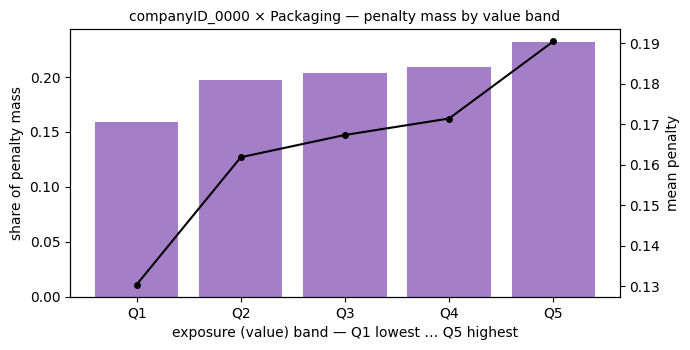

In [50]:
vp = ex.value_phase_profile(scores, RC_VIEW, rc_mask, n_bins=5)
if len(vp):
    display(vp.round(3))
    viz.fig_value_phase(vp, f"{rc_label} — penalty mass by value band", "rc_value_phase")
    hi = vp.loc[vp["value_band"]=="Q5","penalty_mass_share"]
    print(f"\nHigh-value band (Q5) carries {float(hi.iloc[0]):.0%} of the slice's penalty mass.")
else:
    print("Exposure column not available for value-phase profiling.")


### 8.8 Cross-view root-cause summary
For each view's top hotspot, the single strongest contrastive driver and dominant
constraint — a compact "why" companion to the cross-view backlog of Section 4.


In [51]:
rows = []
for v, sl in RC_TARGETS.items():
    m = ex._slice_mask(scores, SLICE_KEYS, sl)
    if m.sum() < 20:
        continue
    c = ex.contrastive_drivers(scores, norm, m, top=1)
    p = ex.constraint_prevalence(scores, norm, m).head(1)
    rows.append({"view": v, "hotspot": " × ".join(map(str, sl)), "cases": int(m.sum()),
                 "top_contrastive_driver": c.iloc[0]["feature"] if len(c) else "—",
                 "cohens_d": round(float(c.iloc[0]["cohens_d"]), 2) if len(c) else None,
                 "dominant_constraint": p.iloc[0]["constraint"] if len(p) else "—",
                 "constraint_layer": p.iloc[0]["layer"] if len(p) else "—"})
display(pd.DataFrame(rows))


,view,hotspot,cases,top_contrastive_driver,cohens_d,dominant_constraint,constraint_layer
0,Finance,companyID_0000 × Packaging,109199,c_l3_invoice_to_clear_days,0.93,c_l3_df2_rpb_to_clear_days,L3_timeliness_ageing
1,Logistics,companyID_0000 × Packaging,109199,c_l3_invoice_to_clear_days,0.93,c_l3_df2_rpb_to_clear_days,L3_timeliness_ageing
2,Compliance,companyID_0000 × Packaging,109199,c_l3_invoice_to_clear_days,0.93,c_l3_df2_rpb_to_clear_days,L3_timeliness_ageing
3,Automation,companyID_0000 × Packaging,109199,c_l3_invoice_to_clear_days,0.93,c_l3_df2_rpb_to_clear_days,L3_timeliness_ageing


In [52]:
# Figure index — everything written by this notebook
files = sorted(Path(CONFIG["figures_dir"]).glob("*.png"))
print(f"FIGURE INDEX — {len(files)} files in {CONFIG['figures_dir']}:\n")
for f in files:
    print(f"  {f.name}")


FIGURE INDEX — 40 files in /Users/ula/code/PhD/WISE/WISE/Untitled/figures/full:

  document_pareto_all_views.png
  document_pareto_automation.png
  document_pareto_compliance.png
  document_pareto_finance.png
  document_pareto_logistics.png
  lag_ecdf_companyid_0000_additives.png
  lag_ecdf_companyid_0000_logistics.png
  lag_ecdf_companyid_0000_packaging.png
  lag_ecdf_companyid_0003_realestate.png
  layer_deltas_automation.png
  layer_deltas_compliance.png
  layer_deltas_finance.png
  layer_deltas_logistics.png
  layer_dominance.png
  layer_weights.png
  ownership_heatmap_automation.png
  ownership_heatmap_compliance.png
  ownership_heatmap_finance.png
  ownership_heatmap_logistics.png
  quarterly_trend_automation.png
  quarterly_trend_compliance.png
  quarterly_trend_finance.png
  quarterly_trend_logistics.png
  rc_contrastive.png
  rc_cooccurrence.png
  rc_handoff.png
  rc_permutation_importance.png
  rc_prevalence_global.png
  rc_prevalence_slice.png
  rc_value_phase.png
  risk_mat

---
## Using this output for the paper
The **main-text figures** come from `WISE_BPIC19_paper_story.ipynb`
(`figures/paper/fig04…fig10`).In **appendix /
supplementary** important are: `document_pareto_all_views.png` (shows the
concentration finding holds in all four views), `view_overlap.png` (visual for
finding 6), `layer_dominance.png` (backs the claim *L3 dominant for
Fin/Log/Compl, L7 for Automation* in Q3.2), and the per-view
`risk_matrix_*` / `ownership_heatmap_*` (demonstrates that "the same computations
are available for Finance and Logistics", Sec. V-C).

**Root-cause figures (Section 8, `rc_*`)** are the strongest material for the
paper's *Future Work / discussion* on linking hotspots to root-cause analysis:
`rc_contrastive` (what separates a hotspot from the rest), `rc_cooccurrence`
(which deviations share a mechanism), `rc_permutation_importance` (global score
drivers), and `rc_prevalence_slice` (the exact leading constraint behind a layer
delta). These are descriptive companions — they generate hypotheses for
workshop-based RCA, they do not estimate causal effects.